In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

candidate_output_dirs = [
    Path.cwd() / "outputs",
    Path.cwd() / "Preprocessing" / "outputs",
    Path.cwd().parent / "Preprocessing" / "outputs",
    Path.cwd().parent / "outputs",
]

OUTPUT_DIR = None
for candidate in candidate_output_dirs:
    if (candidate / "audi_q4_lifecycle_clean.parquet").exists():
        OUTPUT_DIR = candidate.resolve()
        break

if OUTPUT_DIR is None:
    checked = "\n".join(str(path.resolve()) for path in candidate_output_dirs)
    raise FileNotFoundError(f"Could not find lifecycle parquet. Checked:\n{checked}")

df = pd.read_parquet(OUTPUT_DIR / "audi_q4_lifecycle_clean.parquet")
sns.set_theme(style="whitegrid")
print(f"Loaded lifecycle parquet from: {OUTPUT_DIR}")

Loaded lifecycle parquet from: /Users/vakof/Desktop/HOD_car/HOD_car/Preprocessing/outputs


In [2]:
df.shape
df["status"].value_counts(normalize=True)
df["variant"].value_counts(dropna=False)
df[["price_eur", "mileage_km", "vehicle_age_months", "electric_range_km"]].describe()

,price_eur,mileage_km,vehicle_age_months,electric_range_km
count,2517.0,2514.0,2447.000000,2441.0
mean,38742.731426,33251.738663,28.198202,459.534207
std,9797.55848,28444.335341,15.032003,67.272273
min,16490.0,0.0,0.000000,100.0
25%,30480.0,8100.0,10.000000,412.0
50%,37500.0,26934.5,36.000000,466.0
75%,45480.0,51641.25,39.000000,513.0
max,99999.0,198108.0,59.000000,579.0


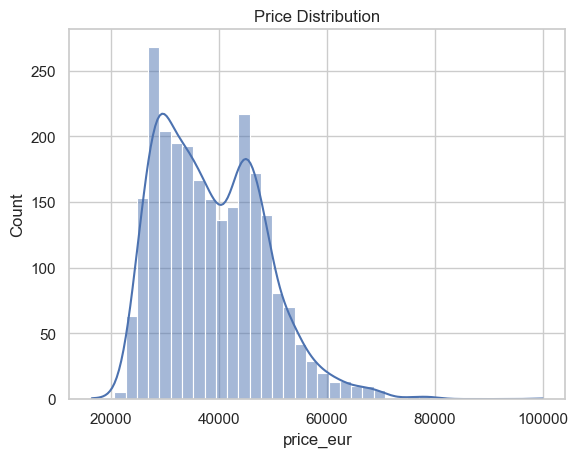

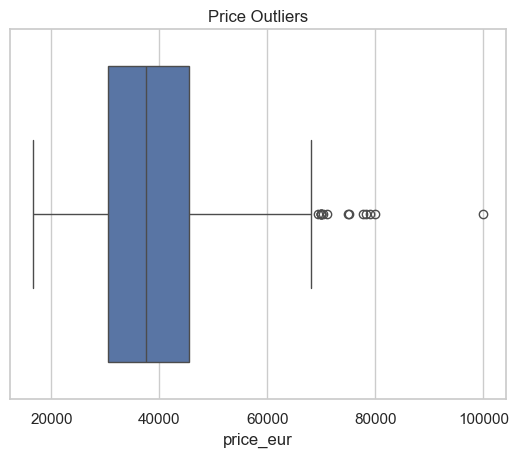

In [3]:
sns.histplot(df["price_eur"], bins=40, kde=True)
plt.title("Price Distribution")
plt.show()

sns.boxplot(x=df["price_eur"])
plt.title("Price Outliers")
plt.show()

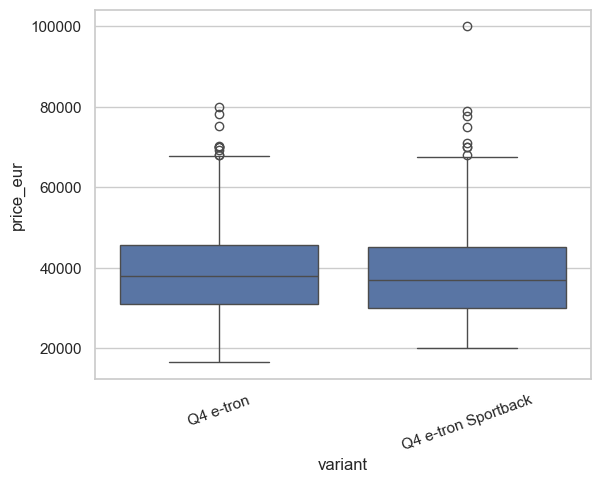

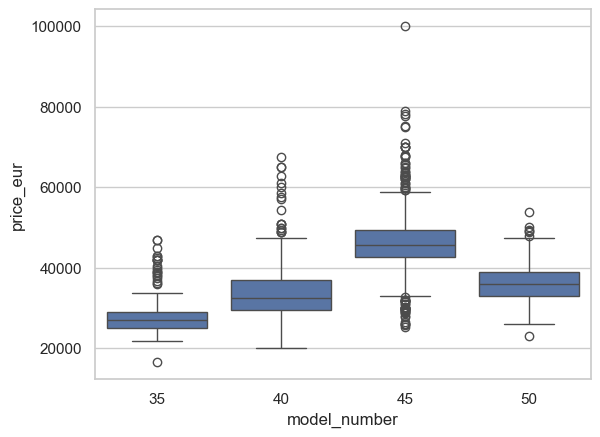

In [4]:
df.groupby("variant")["price_eur"].describe()

sns.boxplot(data=df, x="variant", y="price_eur")
plt.xticks(rotation=20)
plt.show()

sns.boxplot(data=df, x="model_number", y="price_eur", order=["35", "40", "45", "50"])
plt.show()

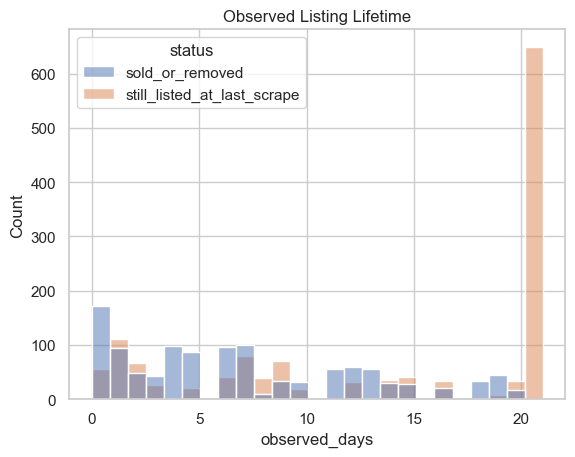

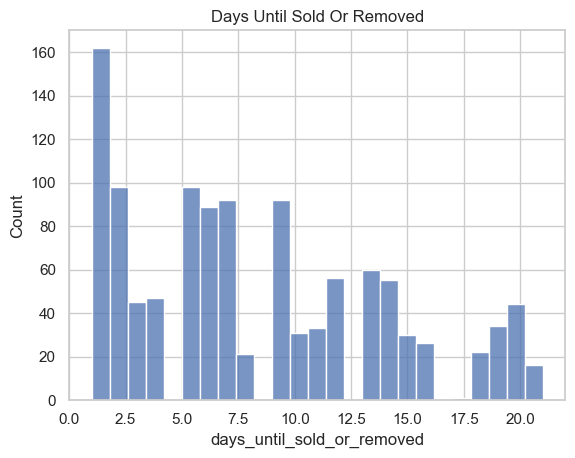

In [5]:
df.groupby("status")[["price_eur", "mileage_km", "observed_days"]].median()

sns.histplot(data=df, x="observed_days", hue="status", bins=25)
plt.title("Observed Listing Lifetime")
plt.show()

sold = df[df["sold_flag"]]

sns.histplot(sold["days_until_sold_or_removed"], bins=25)
plt.title("Days Until Sold Or Removed")
plt.show()

In [6]:
df["price_band"] = pd.qcut(df["price_eur"], q=5, duplicates="drop")
df["mileage_band"] = pd.qcut(df["mileage_km"], q=5, duplicates="drop")

sold_by_price = df.groupby("price_band")["sold_flag"].mean()
sold_by_mileage = df.groupby("mileage_band")["sold_flag"].mean()

sold_by_price
sold_by_mileage

/var/folders/55/sspk_yln3sq0qmc1d37cy3x80000gn/T/ipykernel_99628/3517779996.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sold_by_price = df.groupby("price_band")["sold_flag"].mean()
/var/folders/55/sspk_yln3sq0qmc1d37cy3x80000gn/T/ipykernel_99628/3517779996.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sold_by_mileage = df.groupby("mileage_band")["sold_flag"].mean()


mileage_band
(-0.001, 7387.8]       0.395626
(7387.8, 17468.4]      0.471173
(17468.4, 35295.2]     0.462151
(35295.2, 57632.6]     0.495030
(57632.6, 198108.0]    0.465209
Name: sold_flag, dtype: float64

In [7]:
dupes = df[df["duplicate_listing_id"]].sort_values(["listing_id", "first_seen_timestamp_dt"])

dupes[[
    "listing_id",
    "title",
    "price_eur",
    "mileage_km",
    "listing_url",
    "first_seen_timestamp_dt",
    "last_seen_timestamp_dt",
    "status"
]].head(30)

,listing_id,title,price_eur,mileage_km,listing_url,first_seen_timestamp_dt,last_seen_timestamp_dt,status
392,03b4689d-2ae5-4b3e-a35c-a3767e6117e4,Audi Q4 e-tron 45 quattro,46880,8600,https://www.autoscout24.com/offers/audi-q4-e-t...,2026-04-23,2026-04-29,sold_or_removed
1123,03b4689d-2ae5-4b3e-a35c-a3767e6117e4,Audi Q4 e-tron 45 quattro *ACC*KAM*SPUR*20''*,46690,8600,https://www.autoscout24.com/offers/audi-q4-e-t...,2026-04-30,2026-05-13,sold_or_removed
427,08f37e62-bdab-4e9a-88bf-4d72c8074309,Audi Q4 e-tron e-tron 40 S-Line/Panorama/Kamera,29900,88500,https://www.autoscout24.com/offers/audi-q4-e-t...,2026-04-27,2026-04-30,sold_or_removed
846,08f37e62-bdab-4e9a-88bf-4d72c8074309,Audi Q4 e-tron 40 S-Line/Panorama/Kamera,29900,88500,https://www.autoscout24.com/offers/audi-q4-e-t...,2026-05-02,2026-05-07,sold_or_removed
2279,08f37e62-bdab-4e9a-88bf-4d72c8074309,"Audi Q4 e-tron 40 S-Line/Panorama/Kamera SOH 95,5",29900,88500,https://www.autoscout24.com/offers/audi-q4-e-t...,2026-05-08,2026-05-14,still_listed_at_last_scrape
467,10272eef-be3a-4e0b-854b-95714aeb74c8,Audi Q4 e-tron Q4 Sportback 40 e-tron S line M...,34980,73020,https://www.autoscout24.com/offers/audi-q4-e-t...,2026-04-23,2026-04-30,sold_or_removed
2466,10272eef-be3a-4e0b-854b-95714aeb74c8,Audi Q4 e-tron Q4 Sportback 40 e-tron S line 5...,34980,73020,https://www.autoscout24.com/offers/audi-q4-e-t...,2026-05-02,2026-05-14,still_listed_at_last_scrape
634,1082a29a-6d57-40f4-b0b6-b59eb846eb50,Audi Q4 e-tron Sportback 35 S Line 55kWh RFK/W...,25499,69132,https://www.autoscout24.com/offers/audi-q4-e-t...,2026-04-23,2026-05-04,sold_or_removed
2270,1082a29a-6d57-40f4-b0b6-b59eb846eb50,Audi Q4 e-tron Sportback 35 S Line 55kWh Kamer...,25199,69132,https://www.autoscout24.com/offers/audi-q4-e-t...,2026-05-05,2026-05-14,still_listed_at_last_scrape
666,13d92f3a-c699-4600-a86a-73095de95464,Audi Q4 e-tron e-tron 40,32890,58490,https://www.autoscout24.com/offers/audi-q4-e-t...,2026-05-02,2026-05-05,sold_or_removed


In [8]:
df.groupby("listing_id").agg(
    row_count=("listing_url", "count"),
    min_price=("price_eur", "min"),
    max_price=("price_eur", "max"),
    first_seen=("first_seen_timestamp_dt", "min"),
    last_seen=("last_seen_timestamp_dt", "max")
).query("row_count > 1").sort_values("row_count", ascending=False)

,row_count,min_price,max_price,first_seen,last_seen
listing_id,,,,,
08f37e62-bdab-4e9a-88bf-4d72c8074309,3,29900,29900,2026-04-27,2026-05-14
dac2a5be-33a8-48a5-b175-480309863615,3,53870,53980,2026-04-24,2026-05-11
cc616cef-bdc7-4a04-99db-53c03be08646,3,28299,28748,2026-04-23,2026-05-14
b3febb11-c737-4755-a0bb-fe3b9e417c0a,3,25998,25999,2026-04-23,2026-05-14
1f7de63b-a12e-4b0d-9d25-48bd4d341fbd,3,42910,42910,2026-05-02,2026-05-14
...,...,...,...,...,...
55305af6-a81a-4ef0-aa64-eb26c70d21c7,2,47490,47890,2026-04-23,2026-05-12
54c3ca98-9df1-489c-a1ec-acc49efe37a6,2,35880,35880,2026-05-08,2026-05-14
53531de2-2781-4f5e-8384-954e07153c39,2,48980,48980,2026-05-02,2026-05-14


# Comprehensive Multi-Dataset EDA

This section compares and inspects all four prepared datasets:

- `audi_q4_lifecycle_clean.csv`
- `audi_q4_price_model_dataset.csv`
- `audi_q4_sale_14d_model_dataset.csv`
- `audi_q4_survival_model_dataset.csv`

The focus is ML readiness, leakage detection, target distributions, missingness, outliers, numeric correlations, categorical associations, and lifecycle/sale-speed behavior.

In [9]:
from pathlib import Path
import math
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

pd.set_option("display.max_rows", 120)
pd.set_option("display.max_columns", 120)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11

DATASET_FILES = {
    "lifecycle_clean": "audi_q4_lifecycle_clean.csv",
    "price_model": "audi_q4_price_model_dataset.csv",
    "sale_14d": "audi_q4_sale_14d_model_dataset.csv",
    "survival": "audi_q4_survival_model_dataset.csv",
}

candidate_output_dirs = [
    Path.cwd() / "outputs",
    Path.cwd() / "Preprocessing" / "outputs",
    Path.cwd().parent / "Preprocessing" / "outputs",
    Path.cwd().parent / "outputs",
]

OUTPUT_DIR = None
for candidate in candidate_output_dirs:
    if all((candidate / filename).exists() for filename in DATASET_FILES.values()):
        OUTPUT_DIR = candidate.resolve()
        break

if OUTPUT_DIR is None:
    checked = "\n".join(str(path.resolve()) for path in candidate_output_dirs)
    raise FileNotFoundError(f"Could not find all expected CSV datasets. Checked:\n{checked}")

print(f"Using OUTPUT_DIR: {OUTPUT_DIR}")

def normalize_loaded_types(data):
    data = data.copy()

    for column in data.columns:
        if column.endswith("_dt") or column in ["first_registration_dt"]:
            data[column] = pd.to_datetime(data[column], errors="coerce")

    id_like_columns = ["listing_id", "dealer_id", "zip_code", "model_number", "model_number_v2"]
    for column in id_like_columns:
        if column in data.columns:
            data[column] = data[column].astype("string")

    for column in data.columns:
        if data[column].dtype == "object":
            values = set(data[column].dropna().astype(str).str.lower().unique())
            if values and values <= {"true", "false"}:
                data[column] = (
                    data[column]
                    .astype("string")
                    .str.lower()
                    .map({"true": True, "false": False})
                    .astype("boolean")
                )

    return data

datasets = {}
for name, filename in DATASET_FILES.items():
    csv_path = OUTPUT_DIR / filename
    datasets[name] = normalize_loaded_types(pd.read_csv(csv_path))
    print(f"Loaded {name:16s}: {datasets[name].shape[0]:5d} rows x {datasets[name].shape[1]:3d} columns")

lifecycle_df = datasets["lifecycle_clean"]
price_df = datasets["price_model"]
sale_df = datasets["sale_14d"]
survival_df = datasets["survival"]

Using OUTPUT_DIR: /Users/vakof/Desktop/HOD_car/HOD_car/Preprocessing/outputs
Loaded lifecycle_clean :  2517 rows x 104 columns
Loaded price_model     :  2516 rows x  49 columns
Loaded sale_14d        :  1954 rows x  50 columns
Loaded survival        :  2516 rows x  51 columns


## Helper Functions

These helpers standardize missingness reports, numeric correlation tables, categorical association tables, grouped target summaries, and survival curves.

In [10]:
def display_section(title, level=2):
    display(Markdown(f"{'#' * level} {title}"))


def dataset_inventory(datasets_dict):
    rows = []
    for name, data in datasets_dict.items():
        numeric_count = len(data.select_dtypes(include=["number"]).columns)
        bool_count = len(data.select_dtypes(include=["bool", "boolean"]).columns)
        object_count = len(data.select_dtypes(include=["object", "string", "category"]).columns)
        datetime_count = len(data.select_dtypes(include=["datetime", "datetimetz"]).columns)
        rows.append({
            "dataset": name,
            "rows": len(data),
            "columns": data.shape[1],
            "numeric_cols": numeric_count,
            "boolean_cols": bool_count,
            "categorical_cols": object_count,
            "datetime_cols": datetime_count,
            "duplicate_listing_id_rows": int(data["listing_id"].duplicated(keep=False).sum()) if "listing_id" in data.columns else np.nan,
            "unique_listing_ids": data["listing_id"].nunique(dropna=True) if "listing_id" in data.columns else np.nan,
            "total_missing_pct": data.isna().mean().mean() * 100,
            "memory_mb": data.memory_usage(deep=True).sum() / 1024**2,
        })
    return pd.DataFrame(rows)


def column_profile(data):
    return (
        pd.DataFrame({
            "dtype": data.dtypes.astype(str),
            "missing_count": data.isna().sum(),
            "missing_pct": data.isna().mean() * 100,
            "unique_count": data.nunique(dropna=True),
            "unique_pct": data.nunique(dropna=True) / len(data) * 100,
        })
        .sort_values(["missing_pct", "unique_count"], ascending=[False, False])
    )


def is_boolean_like(series):
    if pd.api.types.is_bool_dtype(series):
        return True
    values = set(series.dropna().astype(str).str.lower().unique())
    return bool(values) and values <= {"true", "false", "0", "1", "0.0", "1.0"}


def boolean_as_float(series):
    if pd.api.types.is_bool_dtype(series):
        return series.astype("Float64").astype(float)
    return (
        series.astype("string")
        .str.lower()
        .map({"true": 1, "false": 0, "1": 1, "0": 0, "1.0": 1, "0.0": 0})
        .astype(float)
    )


def numeric_for_correlation(data, exclude_id_like=True):
    output = pd.DataFrame(index=data.index)
    id_like_tokens = ["id", "url", "phone", "file", "title", "subtitle", "image"]

    for column in data.columns:
        if exclude_id_like and any(token in column.lower() for token in id_like_tokens):
            continue
        if pd.api.types.is_numeric_dtype(data[column]):
            output[column] = pd.to_numeric(data[column], errors="coerce")
        elif is_boolean_like(data[column]):
            output[column] = boolean_as_float(data[column])

    nunique = output.nunique(dropna=True)
    return output.loc[:, nunique > 1]


def safe_qcut(series, q=5):
    numeric = pd.to_numeric(series, errors="coerce")
    try:
        return pd.qcut(numeric, q=q, duplicates="drop")
    except ValueError:
        return pd.Series(pd.NA, index=series.index, dtype="object")


def numeric_target_correlation(data, target, method="spearman", exclude=None):
    exclude = set(exclude or [])
    corr_data = numeric_for_correlation(data).drop(columns=list(exclude), errors="ignore")

    if target not in corr_data.columns:
        corr_data[target] = pd.to_numeric(data[target], errors="coerce")

    corr = corr_data.corr(method=method, min_periods=20)[target].drop(labels=[target], errors="ignore")
    table = pd.DataFrame({
        f"{method}_corr": corr,
        "abs_corr": corr.abs(),
        "non_null_pairs": corr_data.drop(columns=[target], errors="ignore").notna().mul(corr_data[target].notna(), axis=0).sum(),
        "missing_pct": corr_data.drop(columns=[target], errors="ignore").isna().mean() * 100,
    })
    return table.sort_values("abs_corr", ascending=False)


def plot_corr_heatmap(data, title, target=None, method="spearman", max_columns=24, exclude=None):
    exclude = set(exclude or [])
    corr_data = numeric_for_correlation(data).drop(columns=list(exclude), errors="ignore")

    if target and target in data.columns and target not in corr_data.columns:
        corr_data[target] = pd.to_numeric(data[target], errors="coerce")

    corr_data = corr_data.dropna(axis=1, how="all")
    corr_data = corr_data.loc[:, corr_data.nunique(dropna=True) > 1]

    if corr_data.shape[1] < 2:
        print(f"Not enough numeric columns for {title}")
        return

    if target and target in corr_data.columns:
        ordered = (
            corr_data.corr(method=method, min_periods=20)[target]
            .abs()
            .sort_values(ascending=False)
            .head(max_columns)
            .index
            .tolist()
        )
    else:
        ordered = (
            corr_data.notna()
            .mean()
            .sort_values(ascending=False)
            .head(max_columns)
            .index
            .tolist()
        )

    corr = corr_data[ordered].corr(method=method, min_periods=20)
    plt.figure(figsize=(max(10, len(ordered) * 0.55), max(8, len(ordered) * 0.45)))
    sns.heatmap(corr, cmap="vlag", center=0, annot=False, square=False, linewidths=0.2)
    plt.title(title)
    plt.tight_layout()
    plt.show()


def cramers_v(x, y):
    table = pd.crosstab(
        x.astype("string").fillna("<Missing>"),
        y.astype("string").fillna("<Missing>")
    )
    observed = table.to_numpy(dtype=float)
    n = observed.sum()
    if n == 0 or observed.shape[0] < 2 or observed.shape[1] < 2:
        return np.nan

    row_sums = observed.sum(axis=1)
    col_sums = observed.sum(axis=0)
    expected = np.outer(row_sums, col_sums) / n
    mask = expected > 0
    chi2 = (((observed - expected) ** 2) / np.where(expected == 0, np.nan, expected))[mask].sum()
    phi2 = chi2 / n

    r, k = observed.shape
    if n <= 1:
        return np.nan
    phi2corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    rcorr = r - ((r - 1) ** 2) / (n - 1)
    kcorr = k - ((k - 1) ** 2) / (n - 1)
    denominator = min(kcorr - 1, rcorr - 1)
    if denominator <= 0:
        return np.nan
    return math.sqrt(phi2corr / denominator)


def correlation_ratio(categories, measurements):
    temp = pd.DataFrame({
        "category": categories.astype("string").fillna("<Missing>"),
        "value": pd.to_numeric(measurements, errors="coerce"),
    }).dropna(subset=["value"])

    if temp["category"].nunique(dropna=True) < 2 or len(temp) < 3:
        return np.nan

    grand_mean = temp["value"].mean()
    grouped = temp.groupby("category")["value"].agg(["count", "mean"])
    ss_between = (grouped["count"] * (grouped["mean"] - grand_mean) ** 2).sum()
    ss_total = ((temp["value"] - grand_mean) ** 2).sum()
    if ss_total == 0:
        return np.nan
    return math.sqrt(ss_between / ss_total)


def categorical_columns(data, max_unique=60, min_non_null=20):
    candidates = []
    for column in data.columns:
        unique_count = data[column].nunique(dropna=True)
        non_null = data[column].notna().sum()
        if 2 <= unique_count <= max_unique and non_null >= min_non_null:
            if not pd.api.types.is_numeric_dtype(data[column]) or is_boolean_like(data[column]):
                candidates.append(column)
    return candidates


def categorical_association_table(data, target, max_unique=60, min_count=20):
    rows = []
    target_numeric = pd.to_numeric(data[target], errors="coerce") if target in data.columns else None
    binary_target = target_numeric is not None and target_numeric.dropna().nunique() == 2

    for column in categorical_columns(data.drop(columns=[target], errors="ignore"), max_unique=max_unique, min_non_null=min_count):
        valid = data[[column, target]].dropna()
        if len(valid) < min_count:
            continue

        if binary_target:
            score = cramers_v(valid[column], valid[target])
            rates = valid.assign(_target=pd.to_numeric(valid[target], errors="coerce")).groupby(column)["_target"].mean()
            spread = rates.max() - rates.min() if len(rates) else np.nan
            score_name = "cramers_v"
        else:
            score = correlation_ratio(valid[column], valid[target])
            medians = valid.assign(_target=pd.to_numeric(valid[target], errors="coerce")).groupby(column)["_target"].median()
            spread = medians.max() - medians.min() if len(medians) else np.nan
            score_name = "eta"

        rows.append({
            "feature": column,
            score_name: score,
            "target_spread": spread,
            "unique_count": valid[column].nunique(dropna=True),
            "non_null_rows": len(valid),
            "missing_pct": data[column].isna().mean() * 100,
        })

    if not rows:
        return pd.DataFrame()

    result = pd.DataFrame(rows)
    score_column = "cramers_v" if binary_target else "eta"
    return result.sort_values(score_column, ascending=False)


def grouped_target_summary(data, category, target, binary=False, min_count=20, top_n=25):
    temp = data[[category, target]].copy()
    temp[category] = temp[category].astype("string").fillna("<Missing>")
    temp[target] = pd.to_numeric(temp[target], errors="coerce")
    grouped = temp.groupby(category)[target].agg(["count", "mean", "median", "std"])
    grouped = grouped[grouped["count"] >= min_count]
    if binary:
        grouped = grouped.rename(columns={"mean": "target_rate"}).sort_values("target_rate", ascending=False)
    else:
        grouped = grouped.sort_values("median", ascending=False)
    return grouped.head(top_n)


def plot_numeric_histograms(data, columns, title, bins=35):
    columns = [column for column in columns if column in data.columns]
    columns = [column for column in columns if pd.to_numeric(data[column], errors="coerce").notna().sum() > 0]
    if not columns:
        print(f"No numeric columns available for {title}")
        return

    ncols = 3
    nrows = math.ceil(len(columns) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(16, max(4, nrows * 3.3)))
    axes = np.array(axes).reshape(-1)

    for ax, column in zip(axes, columns):
        values = pd.to_numeric(data[column], errors="coerce").dropna()
        sns.histplot(values, bins=bins, kde=True, ax=ax, color="#4C78A8")
        ax.set_title(column)

    for ax in axes[len(columns):]:
        ax.axis("off")

    fig.suptitle(title, y=1.02)
    plt.tight_layout()
    plt.show()


def kaplan_meier_table(data, duration_col="duration_days", event_col="event_sold_or_removed"):
    temp = data[[duration_col, event_col]].dropna().copy()
    temp[duration_col] = pd.to_numeric(temp[duration_col], errors="coerce")
    temp[event_col] = pd.to_numeric(temp[event_col], errors="coerce")
    temp = temp.dropna()
    event_times = sorted(temp.loc[temp[event_col] == 1, duration_col].unique())

    survival = 1.0
    rows = []
    for time in event_times:
        at_risk = (temp[duration_col] >= time).sum()
        events = ((temp[duration_col] == time) & (temp[event_col] == 1)).sum()
        censored = ((temp[duration_col] == time) & (temp[event_col] == 0)).sum()
        if at_risk > 0:
            survival *= (1 - events / at_risk)
        rows.append({
            "duration_days": time,
            "at_risk": at_risk,
            "events": events,
            "censored": censored,
            "survival_probability": survival,
            "sold_or_removed_probability": 1 - survival,
        })
    return pd.DataFrame(rows)

## Dataset Inventory And Schema Comparison

This checks row counts, column counts, feature overlap, missingness, and duplicate listing IDs across all datasets.

In [11]:
inventory = dataset_inventory(datasets)
display(inventory)

all_columns = sorted(set().union(*(set(data.columns) for data in datasets.values())))
schema_presence = pd.DataFrame(index=all_columns)
for name, data in datasets.items():
    schema_presence[name] = schema_presence.index.isin(data.columns)

schema_presence["dataset_count"] = schema_presence[list(datasets.keys())].sum(axis=1)
display(schema_presence.sort_values(["dataset_count"], ascending=False))

common_columns = sorted(set.intersection(*(set(data.columns) for data in datasets.values())))
display(Markdown(f"**Common columns across all datasets:** {len(common_columns)}"))
display(pd.Series(common_columns, name="common_columns"))

for name, data in datasets.items():
    only_here = sorted(set(data.columns) - set().union(*(set(other.columns) for other_name, other in datasets.items() if other_name != name)))
    display(Markdown(f"### Columns only in `{name}` ({len(only_here)})"))
    display(pd.Series(only_here, name=f"only_{name}"))

,dataset,rows,columns,numeric_cols,boolean_cols,categorical_cols,datetime_cols,duplicate_listing_id_rows,unique_listing_ids,total_missing_pct,memory_mb
0,lifecycle_clean,2517,104,23,31,46,4,250,2389,18.733,8.083
1,price_model,2516,49,24,15,10,0,250,2388,6.659,1.943
2,sale_14d,1954,50,25,15,10,0,110,1898,6.497,1.523
3,survival,2516,51,26,15,10,0,250,2388,6.398,1.981


,lifecycle_clean,price_model,sale_14d,survival,dataset_count
seller_rating_stars,True,True,True,True,4
had_accident_clean,True,True,True,True,4
exterior_color,True,True,True,True,4
power_kw,True,True,True,True,4
power_hp,True,True,True,True,4
paint_type,True,True,True,True,4
interior_color,True,True,True,True,4
seller_rating_count,True,True,True,True,4
image_count,True,True,True,True,4
has_pano,True,True,True,True,4


**Common columns across all datasets:** 39

0                available_now_clean
1          battery_charging_time_min
2                          body_type
3                               city
4                         door_count
5               duplicate_listing_id
6                  electric_range_km
7                     exterior_color
8                 had_accident_clean
9                            has_acc
10                           has_ahk
11                        has_camera
12    has_full_service_history_clean
13                           has_hud
14                        has_matrix
15                          has_pano
16                       image_count
17                    interior_color
18        is_conditional_price_clean
19                        is_quattro
20                         is_s_line
21                      is_sportback
22                        listing_id
23                        mileage_km
24                        paint_type
25                          power_hp
26                          power_kw
2

### Columns only in `lifecycle_clean` (65)

...

Series([], Name: only_price_model, dtype: object)

### Columns only in `sale_14d` (1)

0    sold_within_14d
Name: only_sale_14d, dtype: object

### Columns only in `survival` (2)

0            duration_days
1    event_sold_or_removed
Name: only_survival, dtype: object

## Missingness, Cardinality, And Data Quality

This identifies sparse fields, high-cardinality columns, constant columns, and columns that may need special handling before modeling.

### lifecycle_clean: top missing columns

,dtype,missing_count,missing_pct,unique_count,unique_pct
vat_deductible,float64,2517,100.000,0,0.000
delivery_possible,boolean,2503,99.444,1,0.040
delivery_possible_clean,boolean,2503,99.444,1,0.040
has_360_image,boolean,2488,98.848,1,0.040
has_360_image_clean,boolean,2488,98.848,1,0.040
secondary_scrape_error,object,2480,98.530,37,1.470
raw_card_text,object,2460,97.735,55,2.185
electric_range_city,object,2398,95.272,73,2.900
electric_range_city_km,float64,2398,95.272,73,2.900
damage_conditions,object,2384,94.716,1,0.040


Constant / near-constant columns (18): ['vat_deductible', 'delivery_possible', 'delivery_possible_clean', 'has_360_image', 'has_360_image_clean', 'damage_conditions', 'battery_ownership', 'had_accident', 'had_accident_clean', 'price_superscript', 'available_now', 'available_now_clean', 'model_group', 'suspicious_mileage', 'currency', 'country_code', 'battery_charging_time_min', 'suspicious_price']
High-cardinality columns >=50% unique (9): ['primary_image_url', 'mileage_km', 'listing_url', 'listing_id', 'subtitle', 'title', 'mileage', 'price', 'price_eur']


### price_model: top missing columns

,dtype,missing_count,missing_pct,unique_count,unique_pct
battery_charging_time_min,float64,2376,94.436,13,0.517
warranty_months,float64,1912,75.994,28,1.113
wltp_consumption_kwh_100km,float64,1508,59.936,52,2.067
paint_type,object,354,14.070,2,0.079
had_accident_clean,boolean,326,12.957,1,0.040
model_number_v2,string,244,9.698,5,0.199
seller_rating_count,float64,187,7.432,183,7.273
seller_rating_stars,float64,187,7.432,5,0.199
seat_count,float64,175,6.955,2,0.079
previous_owner_count,float64,138,5.485,4,0.159


...

,dtype,missing_count,missing_pct,unique_count,unique_pct
battery_charging_time_min,float64,1840,94.166,13,0.665
warranty_months,float64,1477,75.589,25,1.279
wltp_consumption_kwh_100km,float64,1178,60.287,50,2.559
paint_type,object,280,14.330,2,0.102
had_accident_clean,boolean,256,13.101,1,0.051
model_number_v2,string,169,8.649,5,0.256
seat_count,float64,150,7.677,2,0.102
seller_rating_count,float64,137,7.011,180,9.212
seller_rating_stars,float64,137,7.011,5,0.256
previous_owner_count,float64,95,4.862,4,0.205


Constant / near-constant columns (2): ['had_accident_clean', 'available_now_clean']
High-cardinality columns >=50% unique (7): ['price_per_range_km', 'mileage_per_month', 'mileage_km', 'price_per_hp', 'price_per_kw', 'listing_id', 'price_eur']


### survival: top missing columns

,dtype,missing_count,missing_pct,unique_count,unique_pct
battery_charging_time_min,float64,2376,94.436,13,0.517
warranty_months,float64,1912,75.994,28,1.113
wltp_consumption_kwh_100km,float64,1508,59.936,52,2.067
paint_type,object,354,14.070,2,0.079
had_accident_clean,boolean,326,12.957,1,0.040
model_number_v2,string,244,9.698,5,0.199
seller_rating_count,float64,187,7.432,183,7.273
seller_rating_stars,float64,187,7.432,5,0.199
seat_count,float64,175,6.955,2,0.079
previous_owner_count,float64,138,5.485,4,0.159


Constant / near-constant columns (2): ['had_accident_clean', 'available_now_clean']
High-cardinality columns >=50% unique (7): ['price_per_range_km', 'mileage_per_month', 'mileage_km', 'price_per_hp', 'price_per_kw', 'listing_id', 'price_eur']


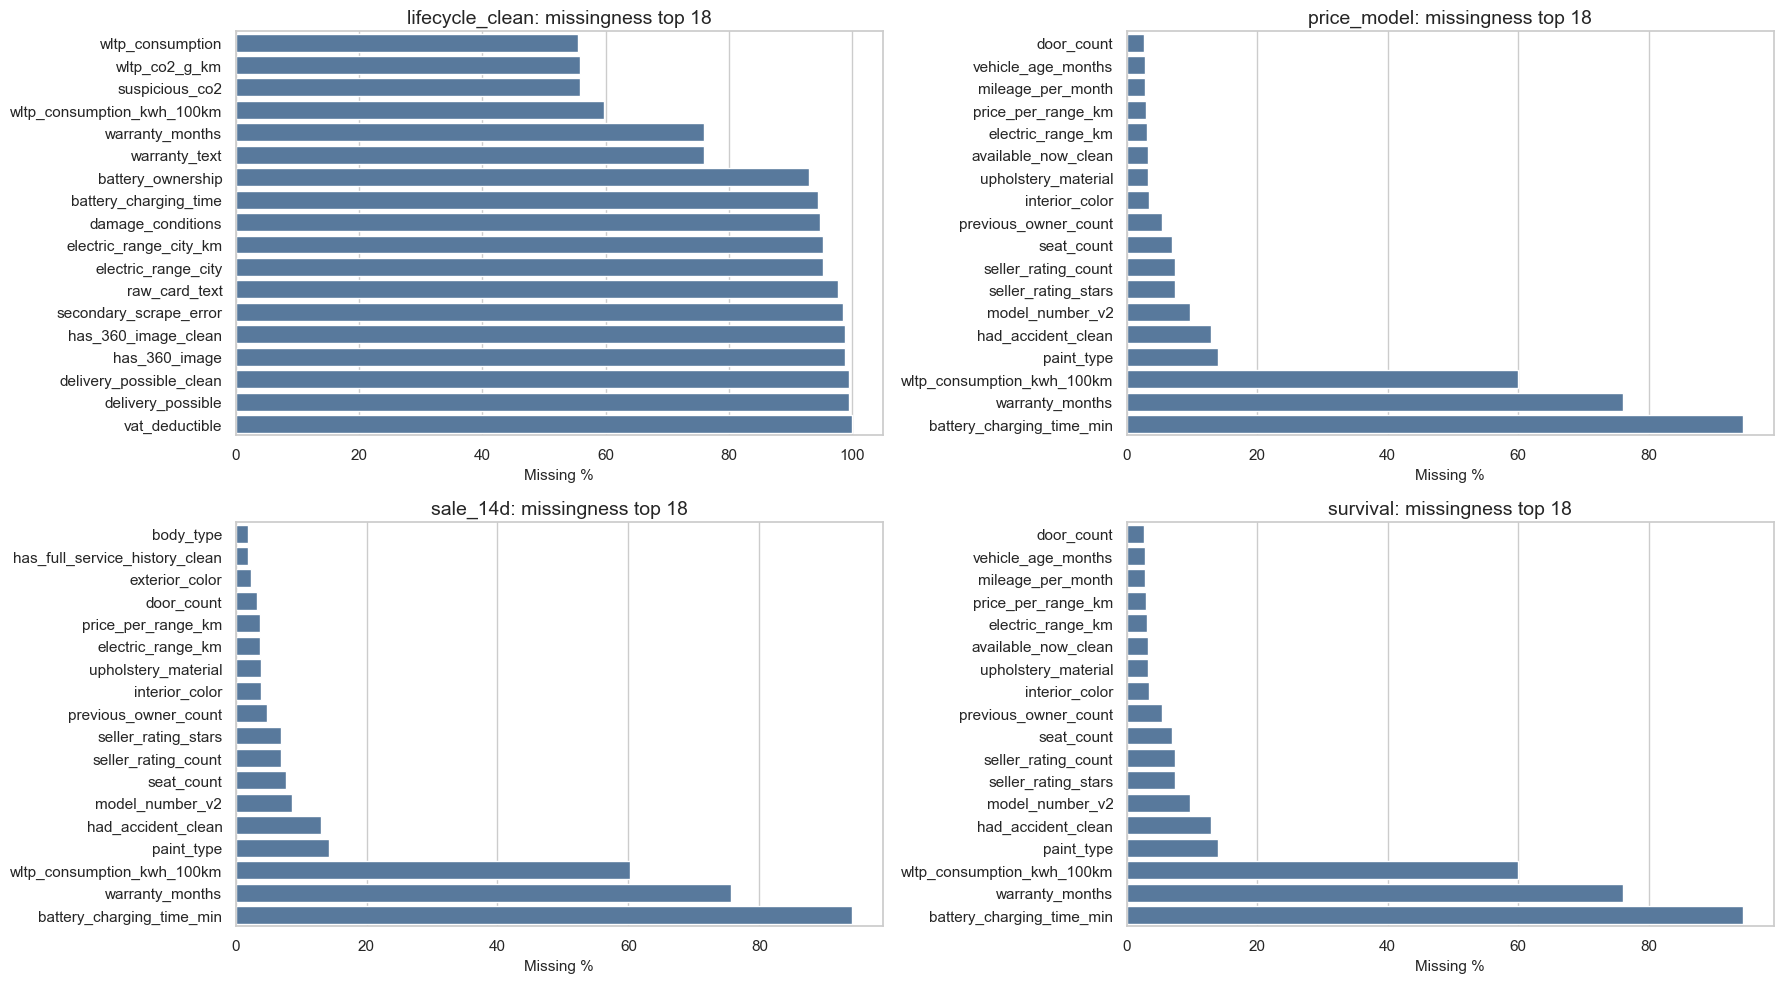

,dataset,target,missing_target_rows,missing_target_pct,target_unique_count
0,lifecycle_clean,price_eur,0,0.000,1278
1,price_model,price_eur,0,0.000,1277
2,sale_14d,price_eur,0,0.000,1089
3,sale_14d,sold_within_14d,0,0.000,2
4,survival,price_eur,0,0.000,1277
5,survival,duration_days,0,0.000,22
6,survival,event_sold_or_removed,0,0.000,2


In [12]:
profiles = {name: column_profile(data) for name, data in datasets.items()}

for name, profile_table in profiles.items():
    display_section(f"{name}: top missing columns", level=3)
    display(profile_table.head(25))

    constant_columns = profile_table[profile_table["unique_count"] <= 1].index.tolist()
    high_cardinality = profile_table[profile_table["unique_pct"] >= 50].index.tolist()

    print(f"Constant / near-constant columns ({len(constant_columns)}): {constant_columns}")
    print(f"High-cardinality columns >=50% unique ({len(high_cardinality)}): {high_cardinality}")

fig, axes = plt.subplots(2, 2, figsize=(18, 10))
axes = axes.reshape(-1)
for ax, (name, profile_table) in zip(axes, profiles.items()):
    top_missing = profile_table.head(18).sort_values("missing_pct")
    sns.barplot(data=top_missing.reset_index(), x="missing_pct", y="index", ax=ax, color="#4C78A8")
    ax.set_title(f"{name}: missingness top 18")
    ax.set_xlabel("Missing %")
    ax.set_ylabel("")
plt.tight_layout()
plt.show()

quality_rows = []
for name, data in datasets.items():
    for target in ["price_eur", "sold_within_14d", "duration_days", "event_sold_or_removed"]:
        if target in data.columns:
            quality_rows.append({
                "dataset": name,
                "target": target,
                "missing_target_rows": int(data[target].isna().sum()),
                "missing_target_pct": data[target].isna().mean() * 100,
                "target_unique_count": data[target].nunique(dropna=True),
            })

display(pd.DataFrame(quality_rows))

## Leakage And Feature Risk Checks

This section flags columns that should not be used directly in certain models. In particular, `price_per_kw`, `price_per_hp`, and `price_per_range_km` are derived from `price_eur`, so they leak the target in the price-prediction dataset.

In [13]:
PRICE_TARGET_LEAKAGE_FEATURES = [
    "price_per_kw",
    "price_per_hp",
    "price_per_range_km",
]

TIME_TARGET_LEAKAGE_FEATURES = [
    "status",
    "sold_flag",
    "is_censored",
    "observed_days",
    "days_until_sold_or_removed",
    "duration_days",
    "event_sold_or_removed",
    "sold_timestamp",
    "sold_timestamp_dt",
    "sold_in_file",
    "last_seen_timestamp",
    "last_seen_timestamp_dt",
    "last_seen_file",
]

leakage_rows = []
for name, data in datasets.items():
    if name == "price_model":
        for column in PRICE_TARGET_LEAKAGE_FEATURES:
            leakage_rows.append({
                "dataset": name,
                "column": column,
                "present": column in data.columns,
                "risk": "Target leakage for price prediction because it is computed using price_eur.",
            })
    for column in TIME_TARGET_LEAKAGE_FEATURES:
        if column in data.columns:
            leakage_rows.append({
                "dataset": name,
                "column": column,
                "present": True,
                "risk": "Do not use as a feature unless it is the target or survival/censoring metadata.",
            })

leakage_table = pd.DataFrame(leakage_rows)
display(leakage_table)

safe_price_feature_df = price_df.drop(columns=PRICE_TARGET_LEAKAGE_FEATURES, errors="ignore")
print("Price-model feature columns after removing obvious target-derived leakage:")
print(safe_price_feature_df.drop(columns=["price_eur", "listing_id"], errors="ignore").columns.tolist())

,dataset,column,present,risk
0,lifecycle_clean,status,True,Do not use as a feature unless it is the targe...
1,lifecycle_clean,sold_flag,True,Do not use as a feature unless it is the targe...
2,lifecycle_clean,is_censored,True,Do not use as a feature unless it is the targe...
3,lifecycle_clean,observed_days,True,Do not use as a feature unless it is the targe...
4,lifecycle_clean,days_until_sold_or_removed,True,Do not use as a feature unless it is the targe...
5,lifecycle_clean,sold_timestamp,True,Do not use as a feature unless it is the targe...
6,lifecycle_clean,sold_timestamp_dt,True,Do not use as a feature unless it is the targe...
7,lifecycle_clean,sold_in_file,True,Do not use as a feature unless it is the targe...
8,lifecycle_clean,last_seen_timestamp,True,Do not use as a feature unless it is the targe...
9,lifecycle_clean,last_seen_timestamp_dt,True,Do not use as a feature unless it is the targe...


Price-model feature columns after removing obvious target-derived leakage:
['mileage_km', 'vehicle_age_months', 'power_kw', 'power_hp', 'electric_range_km', 'wltp_consumption_kwh_100km', 'seller_rating_stars', 'seller_rating_count', 'image_count', 'previous_owner_count', 'door_count', 'seat_count', 'warranty_months', 'battery_charging_time_min', 'mileage_per_month', 'variant', 'model_number_v2', 'seller_type', 'body_type', 'exterior_color', 'paint_type', 'interior_color', 'upholstery_material', 'city', 'is_conditional_price_clean', 'available_now_clean', 'warranty_exists_clean', 'has_full_service_history_clean', 'had_accident_clean', 'is_sportback', 'is_quattro', 'is_s_line', 'has_matrix', 'has_pano', 'has_ahk', 'has_hud', 'has_acc', 'has_camera', 'duplicate_listing_id', 'seller_has_rating', 'has_warranty_months', 'has_battery_info', 'has_city_range', 'has_charging_time']


## Lifecycle Clean Dataset EDA

The lifecycle dataset is the broad audit table. Use it to understand scrape health, listing status, repeated listing IDs, market composition, and lifecycle timing.

### Lifecycle status and scrape health

**status**

,count,pct
status,,
still_listed_at_last_scrape,1365,54.231
sold_or_removed,1152,45.769


**secondary_scrape_status**

,count,pct
secondary_scrape_status,,
ok,2480,98.530
error,37,1.470


...

**fuel_or_powertrain**

,count,pct
fuel_or_powertrain,,
Electric,2516,99.960
Electric/Gasoline,1,0.040


**transmission**

,count,pct
transmission,,
Automatic,2512,99.801
- Gear,4,0.159
Manual,1,0.040


,metric,value
0,rows,2517
1,unique_listing_ids,2389
2,duplicate_listing_id_rows,250
3,unique_listing_urls,2517
4,sold_or_removed_rows,1152
5,still_listed_rows,1365
6,scrape_error_rows,37


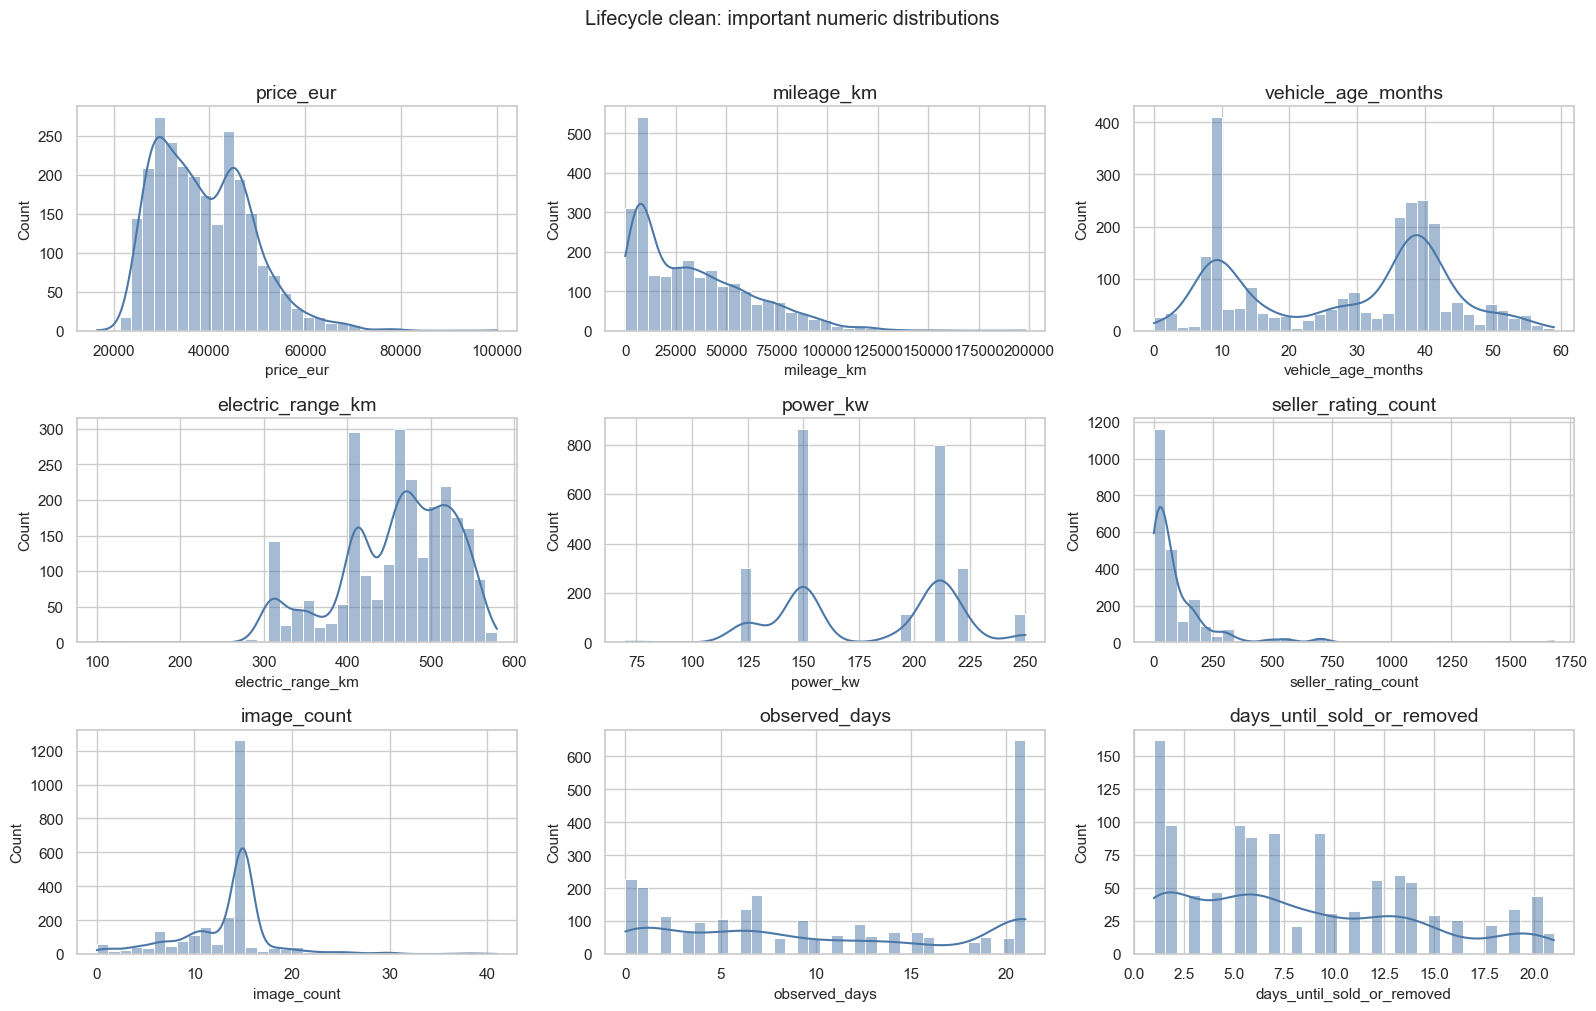

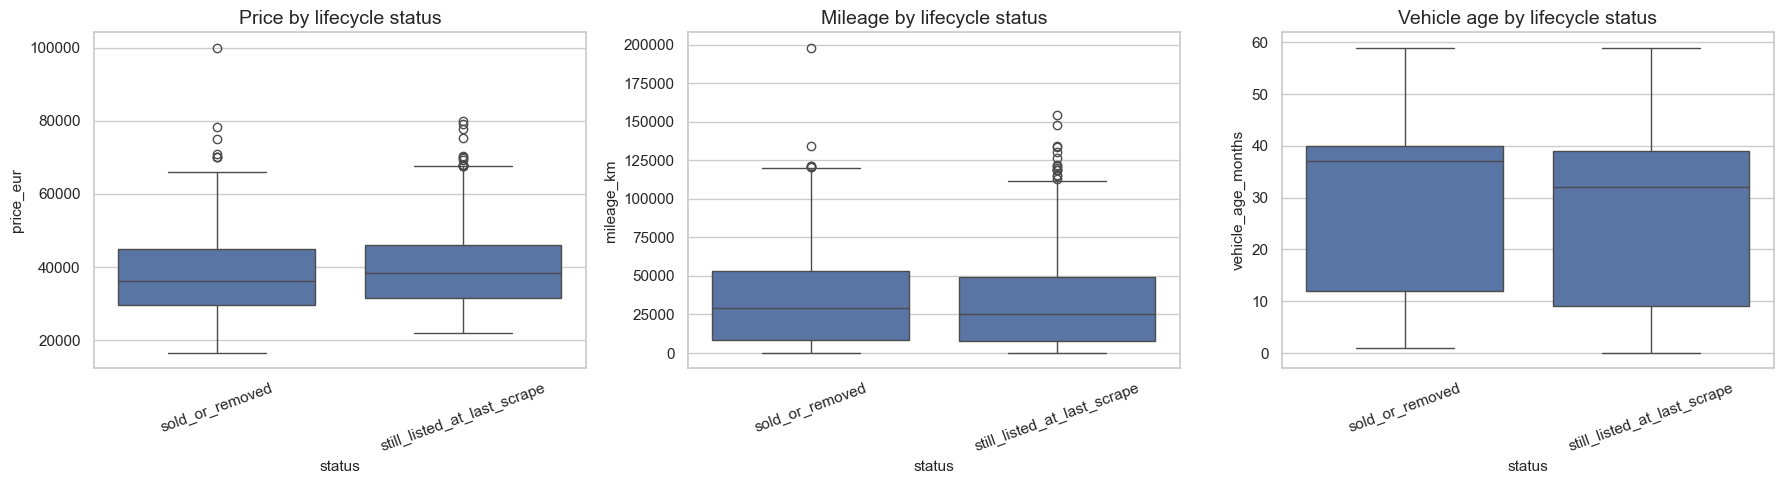

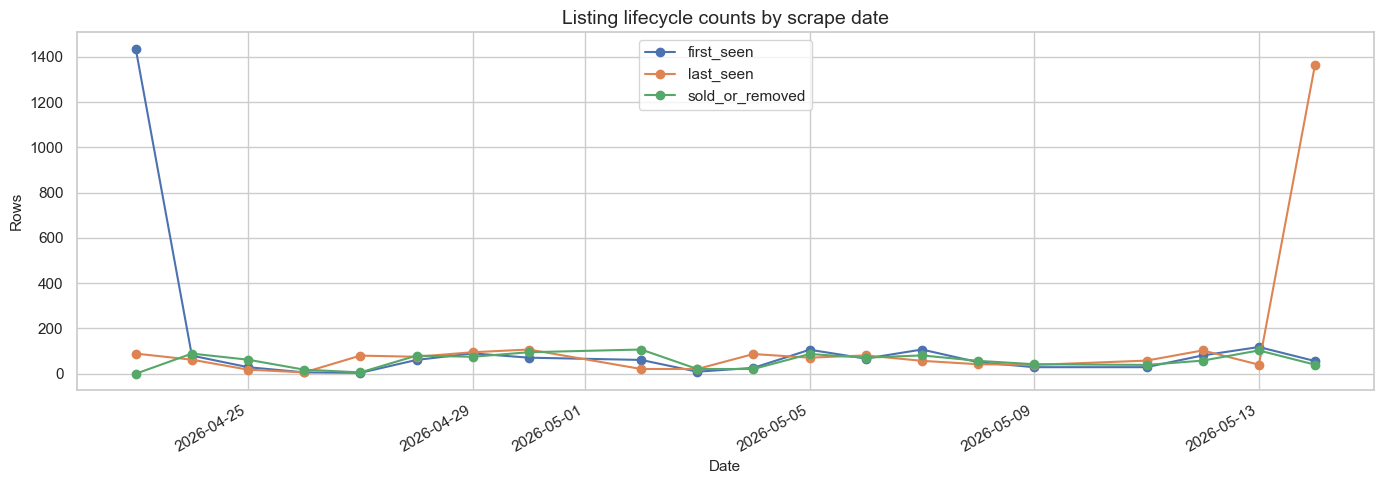

,first_seen,last_seen,sold_or_removed
2026-04-23,1436,89,0.000
2026-04-24,80,62,89.000
2026-04-25,29,18,62.000
2026-04-26,6,6,18.000
2026-04-27,4,80,6.000
2026-04-28,61,75,80.000
2026-04-29,90,95,75.000
2026-04-30,71,107,95.000
2026-05-02,61,21,107.000
2026-05-03,9,21,21.000


In [14]:
display_section("Lifecycle status and scrape health", level=3)
for column in ["status", "secondary_scrape_status", "variant", "model_number", "seller_type", "fuel_or_powertrain", "transmission"]:
    if column in lifecycle_df.columns:
        display(Markdown(f"**{column}**"))
        display(lifecycle_df[column].value_counts(dropna=False).to_frame("count").assign(pct=lambda table: table["count"] / len(lifecycle_df) * 100))

lifecycle_quality = pd.DataFrame({
    "metric": [
        "rows",
        "unique_listing_ids",
        "duplicate_listing_id_rows",
        "unique_listing_urls",
        "sold_or_removed_rows",
        "still_listed_rows",
        "scrape_error_rows",
    ],
    "value": [
        len(lifecycle_df),
        lifecycle_df["listing_id"].nunique(dropna=True) if "listing_id" in lifecycle_df else np.nan,
        lifecycle_df["listing_id"].duplicated(keep=False).sum() if "listing_id" in lifecycle_df else np.nan,
        lifecycle_df["listing_url"].nunique(dropna=True) if "listing_url" in lifecycle_df else np.nan,
        lifecycle_df["status"].eq("sold_or_removed").sum() if "status" in lifecycle_df else np.nan,
        lifecycle_df["status"].eq("still_listed_at_last_scrape").sum() if "status" in lifecycle_df else np.nan,
        lifecycle_df["secondary_scrape_status"].eq("error").sum() if "secondary_scrape_status" in lifecycle_df else np.nan,
    ],
})
display(lifecycle_quality)

plot_numeric_histograms(
    lifecycle_df,
    ["price_eur", "mileage_km", "vehicle_age_months", "electric_range_km", "power_kw", "seller_rating_count", "image_count", "observed_days", "days_until_sold_or_removed"],
    "Lifecycle clean: important numeric distributions",
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
if "price_eur" in lifecycle_df.columns and "status" in lifecycle_df.columns:
    sns.boxplot(data=lifecycle_df, x="status", y="price_eur", ax=axes[0])
    axes[0].set_title("Price by lifecycle status")
    axes[0].tick_params(axis="x", rotation=20)
if "mileage_km" in lifecycle_df.columns and "status" in lifecycle_df.columns:
    sns.boxplot(data=lifecycle_df, x="status", y="mileage_km", ax=axes[1])
    axes[1].set_title("Mileage by lifecycle status")
    axes[1].tick_params(axis="x", rotation=20)
if "vehicle_age_months" in lifecycle_df.columns and "status" in lifecycle_df.columns:
    sns.boxplot(data=lifecycle_df, x="status", y="vehicle_age_months", ax=axes[2])
    axes[2].set_title("Vehicle age by lifecycle status")
    axes[2].tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

if {"first_seen_timestamp_dt", "last_seen_timestamp_dt"}.issubset(lifecycle_df.columns):
    timeline = pd.DataFrame({
        "first_seen": lifecycle_df.groupby("first_seen_timestamp_dt").size(),
        "last_seen": lifecycle_df.groupby("last_seen_timestamp_dt").size(),
    }).fillna(0)
    if "sold_timestamp_dt" in lifecycle_df.columns:
        timeline["sold_or_removed"] = lifecycle_df.dropna(subset=["sold_timestamp_dt"]).groupby("sold_timestamp_dt").size()
    timeline = timeline.fillna(0).sort_index()

    timeline.plot(figsize=(14, 5), marker="o")
    plt.title("Listing lifecycle counts by scrape date")
    plt.ylabel("Rows")
    plt.xlabel("Date")
    plt.tight_layout()
    plt.show()
    display(timeline)

In [15]:
display_section("Lifecycle status rates by segments", level=3)
segment_df = lifecycle_df.copy()
if "price_eur" in segment_df.columns:
    segment_df["price_band"] = safe_qcut(segment_df["price_eur"], q=5)
if "mileage_km" in segment_df.columns:
    segment_df["mileage_band"] = safe_qcut(segment_df["mileage_km"], q=5)
if "vehicle_age_months" in segment_df.columns:
    segment_df["age_band"] = safe_qcut(segment_df["vehicle_age_months"], q=5)

for category in ["variant", "model_number", "seller_type", "body_type", "exterior_color", "price_band", "mileage_band", "age_band"]:
    if category in segment_df.columns and "sold_flag" in segment_df.columns:
        display(Markdown(f"**Sold/removed rate by {category}**"))
        display(grouped_target_summary(segment_df, category, "sold_flag", binary=True, min_count=20, top_n=30))

if "listing_id" in lifecycle_df.columns:
    relisting_table = (
        lifecycle_df.groupby("listing_id")
        .agg(
            row_count=("listing_id", "size"),
            first_seen=("first_seen_timestamp_dt", "min") if "first_seen_timestamp_dt" in lifecycle_df.columns else ("listing_id", "size"),
            last_seen=("last_seen_timestamp_dt", "max") if "last_seen_timestamp_dt" in lifecycle_df.columns else ("listing_id", "size"),
            min_price=("price_eur", "min") if "price_eur" in lifecycle_df.columns else ("listing_id", "size"),
            max_price=("price_eur", "max") if "price_eur" in lifecycle_df.columns else ("listing_id", "size"),
            status_count=("status", "nunique") if "status" in lifecycle_df.columns else ("listing_id", "size"),
        )
        .query("row_count > 1")
        .assign(price_range=lambda table: table["max_price"] - table["min_price"])
        .sort_values(["row_count", "price_range"], ascending=False)
    )
    display_section("Repeated listing_id / relisting behavior", level=3)
    display(relisting_table.head(40))

### Lifecycle status rates by segments

**Sold/removed rate by variant**

,count,target_rate,median,std
variant,,,,
Q4 e-tron,1655,0.459,0.000,0.498
Q4 e-tron Sportback,849,0.448,0.000,0.498


**Sold/removed rate by model_number**

,count,target_rate,median,std
model_number,,,,
50.0,272,0.504,1.000,0.501
40.0,783,0.481,0.000,0.500
45.0,822,0.444,0.000,0.497
<Missing>,370,0.430,0.000,0.496
35.0,270,0.422,0.000,0.495


...

,count,target_rate,median,std
mileage_band,,,,
"(35295.2, 57632.6]",503,0.495,0.000,0.500
"(7387.8, 17468.4]",503,0.471,0.000,0.500
"(57632.6, 198108.0]",503,0.465,0.000,0.499
"(17468.4, 35295.2]",502,0.462,0.000,0.499
"(-0.001, 7387.8]",503,0.396,0.000,0.489


**Sold/removed rate by age_band**

,count,target_rate,median,std
age_band,,,,
"(38.0, 41.0]",386,0.554,1.000,0.498
"(41.0, 59.0]",373,0.507,1.000,0.501
"(9.0, 26.0]",448,0.475,0.000,0.500
"(26.0, 38.0]",697,0.452,0.000,0.498
"(-0.001, 9.0]",543,0.368,0.000,0.483
<Missing>,70,0.300,0.000,0.462


### Repeated listing_id / relisting behavior

,row_count,first_seen,last_seen,min_price,max_price,status_count,price_range
listing_id,,,,,,,
cc616cef-bdc7-4a04-99db-53c03be08646,3,2026-04-23,2026-05-14,28299,28748,2,449
dac2a5be-33a8-48a5-b175-480309863615,3,2026-04-24,2026-05-11,53870,53980,1,110
b3febb11-c737-4755-a0bb-fe3b9e417c0a,3,2026-04-23,2026-05-14,25998,25999,2,1
08f37e62-bdab-4e9a-88bf-4d72c8074309,3,2026-04-27,2026-05-14,29900,29900,2,0
1f7de63b-a12e-4b0d-9d25-48bd4d341fbd,3,2026-05-02,2026-05-14,42910,42910,2,0
87c4c697-9910-4557-8ae7-7d154f820664,3,2026-04-24,2026-05-12,52490,52490,1,0
ac6868cb-bd8b-4d87-96a9-e8ff59240377,2,2026-04-23,2026-05-14,57990,69990,2,12000
148922cd-5e3f-4439-bf28-e76cc7bbe306,2,2026-04-23,2026-05-14,42950,52950,2,10000
57db28dc-1be9-49ab-a906-6f1b8a93b4cf,2,2026-05-05,2026-05-14,44930,48930,2,4000


## Lifecycle Correlation Inspection

This checks numeric correlations with price, lifecycle duration, and sold/removed status in the broad lifecycle table.

### Lifecycle numeric correlations with price_eur

,spearman_corr,abs_corr,non_null_pairs,missing_pct
vehicle_age_months,-0.795,0.795,2447,2.781
mileage_km,-0.770,0.770,2514,0.119
warranty_months,0.656,0.656,604,76.003
power_hp,0.638,0.638,2514,0.119
power_kw,0.638,0.638,2514,0.119
electric_range_km,0.386,0.386,2441,3.019
has_ahk,0.251,0.251,2517,0.000
is_s_line,0.179,0.179,2517,0.000
is_quattro,0.170,0.170,2517,0.000
has_matrix,0.158,0.158,2517,0.000


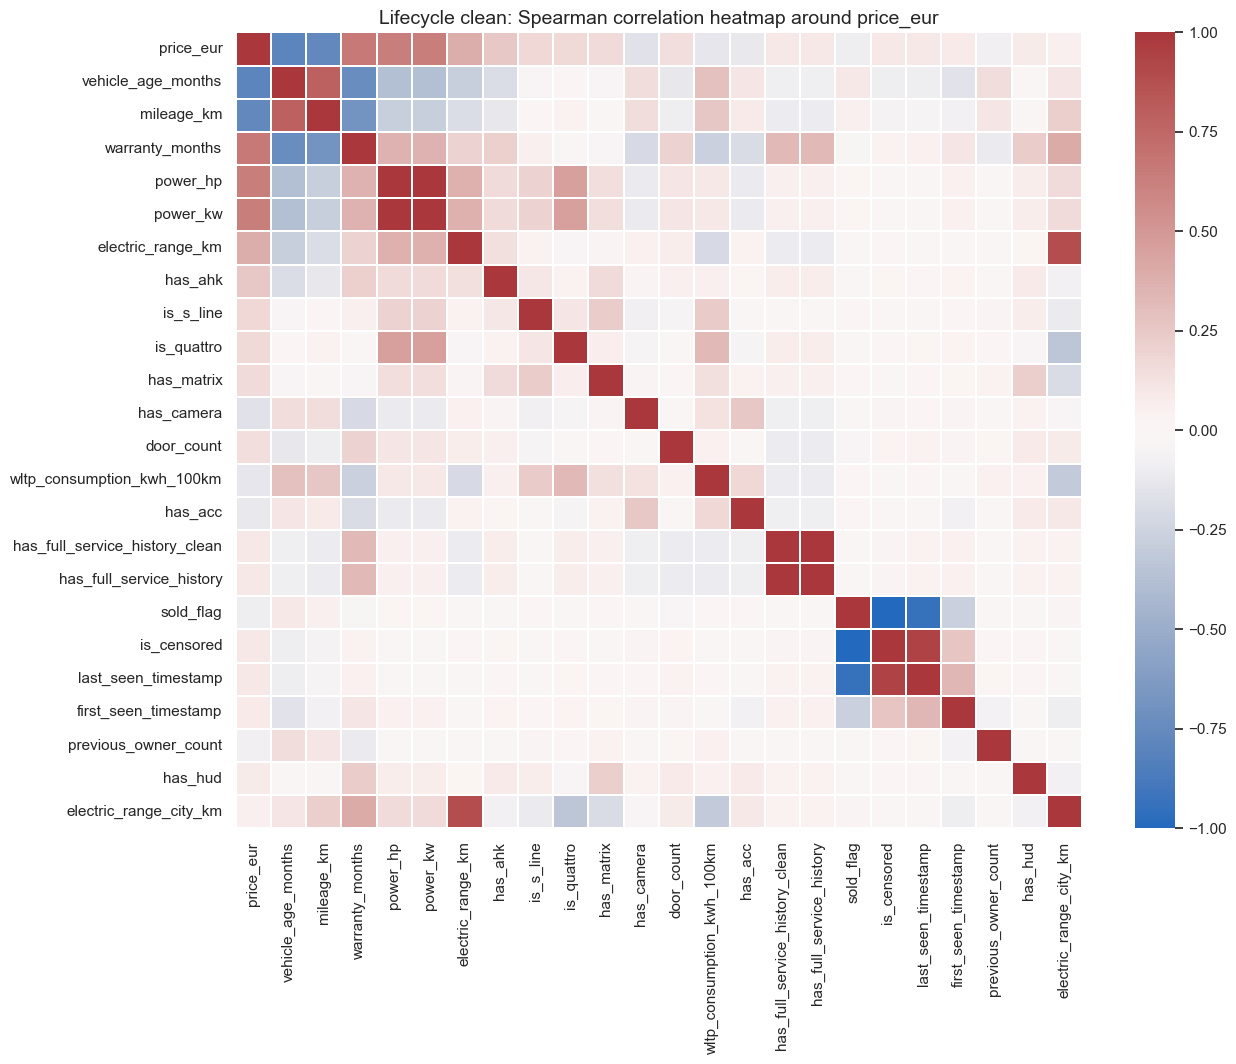

### Lifecycle numeric correlations with sold_flag

,spearman_corr,abs_corr,non_null_pairs,missing_pct
is_censored,-1.000,1.000,2517,0.000
last_seen_timestamp,-0.941,0.941,2517,0.000
observed_days,-0.441,0.441,2517,0.000
first_seen_timestamp,-0.273,0.273,2517,0.000
scrape_error_flag,0.133,0.133,2517,0.000
vehicle_age_months,0.099,0.099,2447,2.781
price_eur,-0.096,0.096,2517,0.000
mileage_km,0.056,0.056,2514,0.119
warranty_months,-0.045,0.045,604,76.003
suspicious_wltp,0.043,0.043,2517,0.000


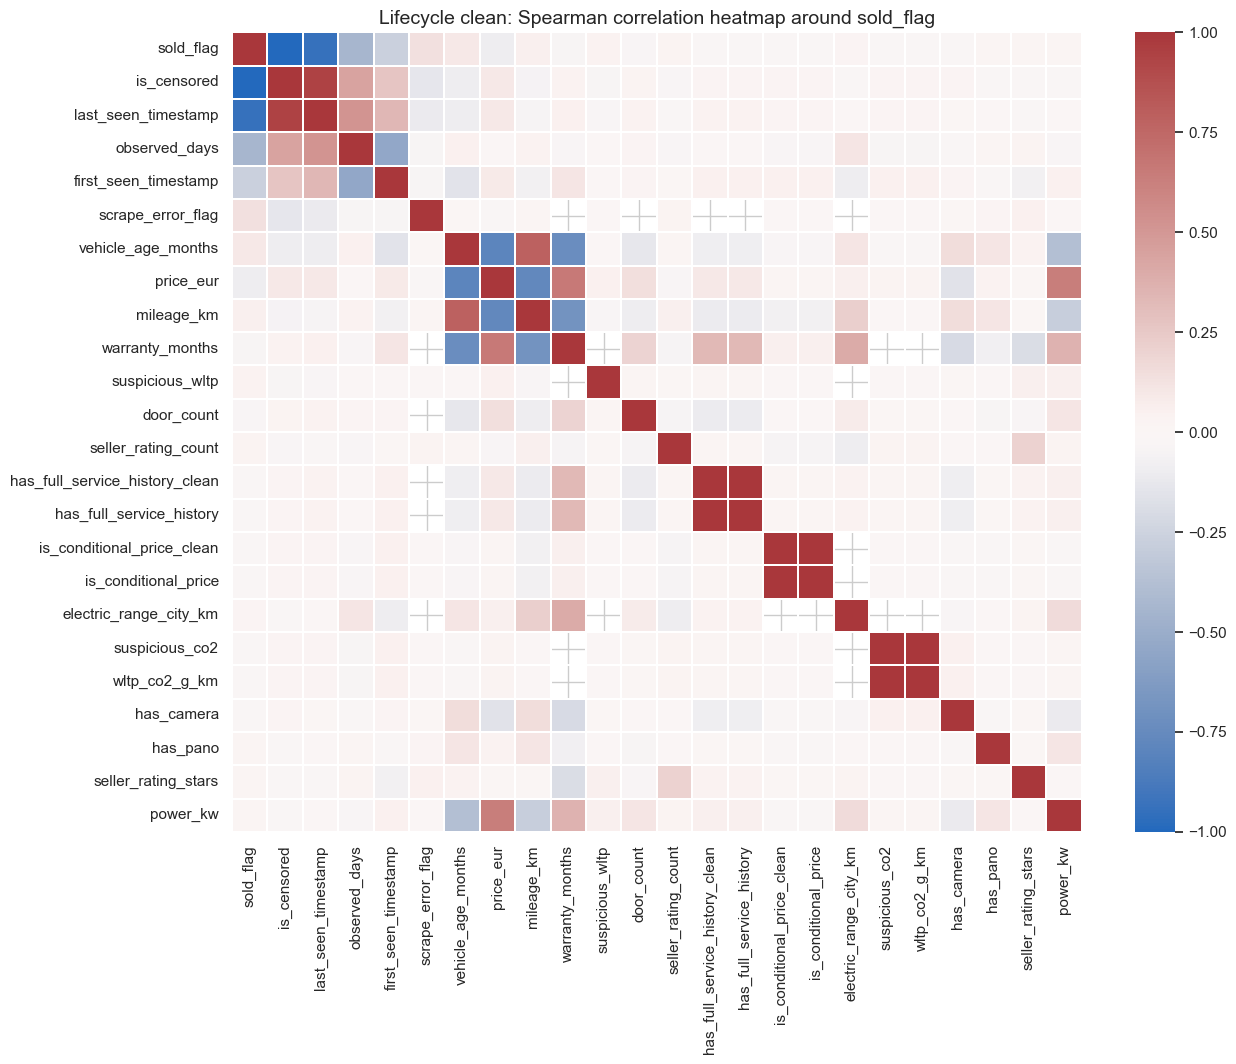

### Lifecycle numeric correlations with days_until_sold_or_removed

,spearman_corr,abs_corr,non_null_pairs,missing_pct
observed_days,0.999,0.999,1152,0.000
last_seen_timestamp,0.609,0.609,1152,0.000
sold_timestamp,0.609,0.609,1152,54.231
first_seen_timestamp,-0.335,0.335,1152,0.000
electric_range_city_km,0.117,0.117,31,95.272
previous_owner_count,0.089,0.089,1082,5.483
wltp_consumption_kwh_100km,0.088,0.088,421,59.793
door_count,0.084,0.084,1096,2.662
has_full_service_history,0.059,0.059,1114,1.510
has_full_service_history_clean,0.059,0.059,1114,1.510


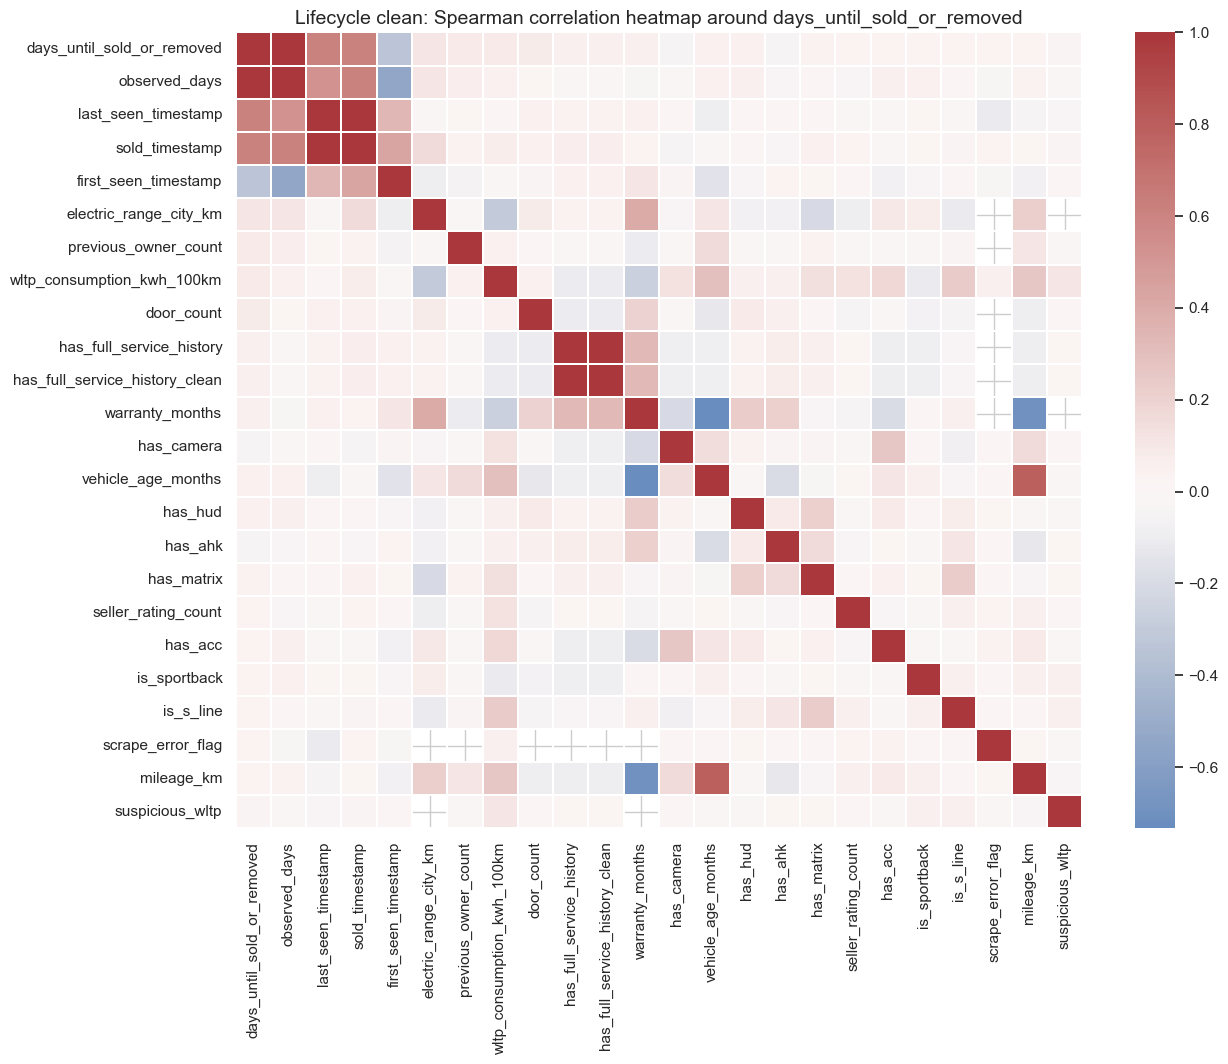

### Lifecycle numeric correlations with observed_days

,spearman_corr,abs_corr,non_null_pairs,missing_pct
days_until_sold_or_removed,0.999,0.999,1152,54.231
sold_timestamp,0.608,0.608,1152,54.231
first_seen_timestamp,-0.542,0.542,2517,0.000
last_seen_timestamp,0.519,0.519,2517,0.000
sold_flag,-0.441,0.441,2517,0.000
is_censored,0.441,0.441,2517,0.000
electric_range_city_km,0.110,0.110,119,95.272
previous_owner_count,0.066,0.066,2379,5.483
has_acc,0.055,0.055,2517,0.000
has_hud,0.054,0.054,2517,0.000


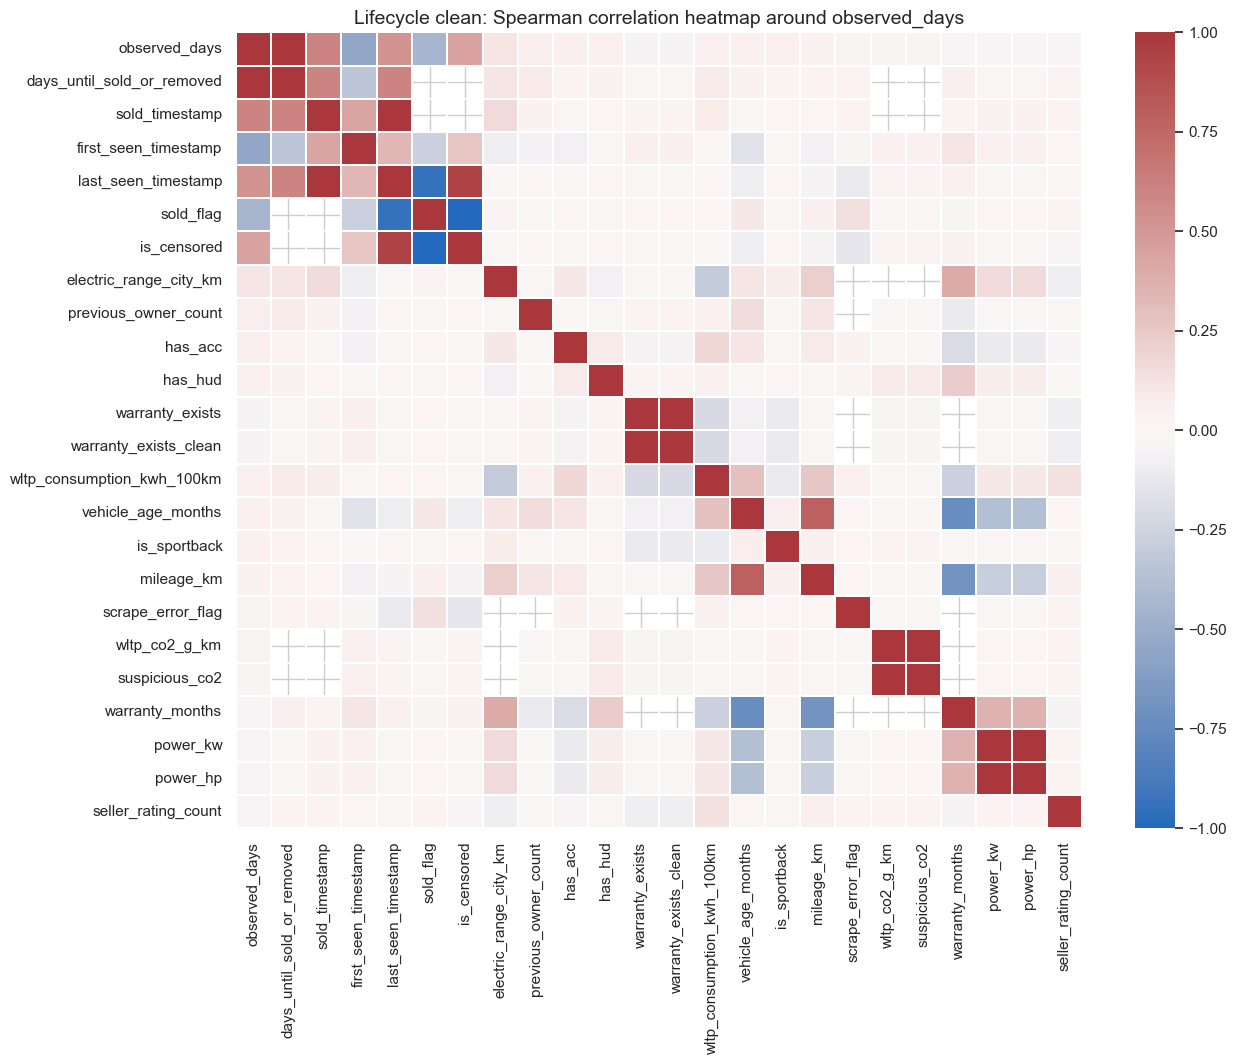

### Lifecycle categorical associations with price_eur

,feature,eta,target_spread,unique_count,non_null_rows,missing_pct
8,raw_card_text,1.000,"50,312.000",55,57,97.735
20,secondary_scrape_error,1.000,"26,291.000",37,37,98.530
18,electric_range_city,0.950,"46,019.000",73,119,95.272
28,first_registration_dt,0.843,"33,250.000",59,2447,2.781
3,first_registration,0.841,"33,250.000",60,2517,0.000
43,model_number,0.713,"18,724.500",4,2147,14.700
10,warranty_text,0.673,"35,000.000",28,604,76.003
17,battery_charging_time,0.570,"23,880.000",13,140,94.438
5,wltp_consumption,0.451,"31,712.000",54,1118,55.582
16,upholstery_material,0.262,"18,761.000",6,2434,3.298


### Lifecycle categorical associations with sold_flag

,feature,cramers_v,target_spread,unique_count,non_null_rows,missing_pct
24,status,1.000,1.000,2,2517,0.000
29,is_censored,1.000,1.000,2,2517,0.000
26,last_seen_timestamp_dt,0.996,1.000,20,2517,0.000
22,last_seen_file,0.996,1.000,20,2517,0.000
18,electric_range_city,0.407,1.000,73,119,95.272
25,first_seen_timestamp_dt,0.317,1.000,20,2517,0.000
21,first_seen_file,0.317,1.000,20,2517,0.000
8,raw_card_text,0.191,1.000,55,57,97.735
5,wltp_consumption,0.177,1.000,54,1118,55.582
3,first_registration,0.175,0.800,60,2517,0.000


In [16]:
for target in ["price_eur", "sold_flag", "days_until_sold_or_removed", "observed_days"]:
    if target in lifecycle_df.columns:
        display_section(f"Lifecycle numeric correlations with {target}", level=3)
        corr_table = numeric_target_correlation(lifecycle_df, target, method="spearman")
        display(corr_table.head(30))
        plot_corr_heatmap(lifecycle_df, f"Lifecycle clean: Spearman correlation heatmap around {target}", target=target, max_columns=24)

for target in ["price_eur", "sold_flag"]:
    if target in lifecycle_df.columns:
        display_section(f"Lifecycle categorical associations with {target}", level=3)
        display(categorical_association_table(lifecycle_df, target, max_unique=80, min_count=30).head(30))

## Price Model Dataset EDA

This dataset is for predicting asking price. Do not use columns derived from `price_eur` as predictors for a real price model.

### Price target distribution

,price_eur
count,"2,516.000"
mean,"38,718.385"
std,"9,723.052"
min,"16,490.000"
1%,"23,990.000"
5%,"25,717.500"
25%,"30,480.000"
50%,"37,500.000"
75%,"45,480.000"
95%,"55,391.500"


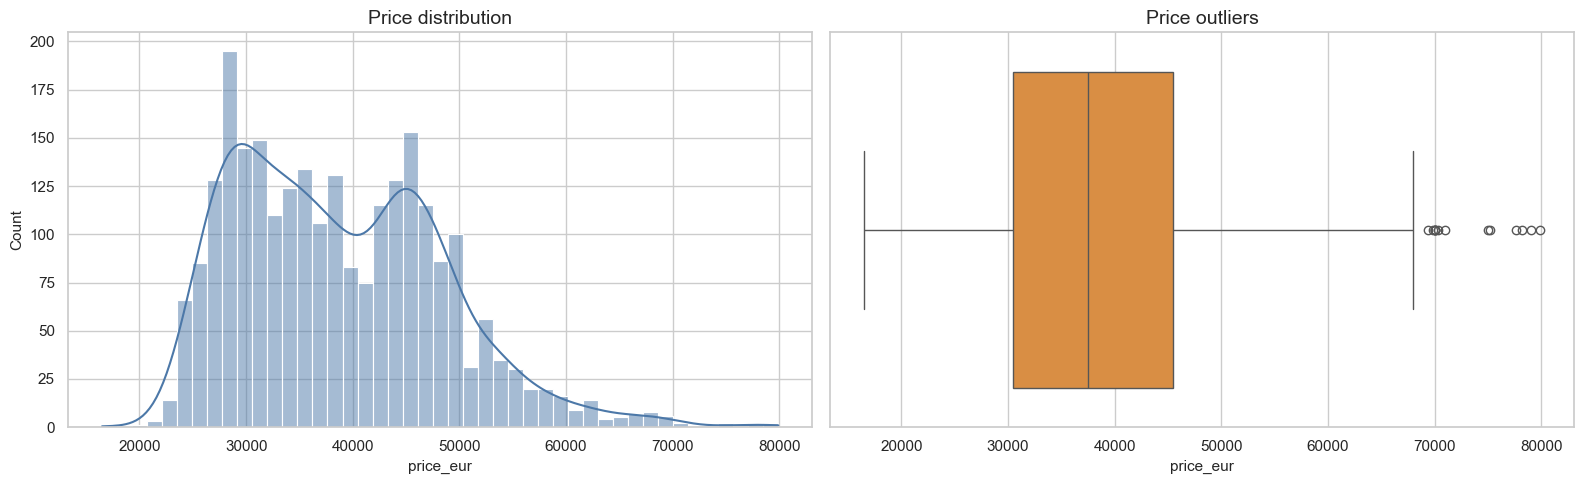

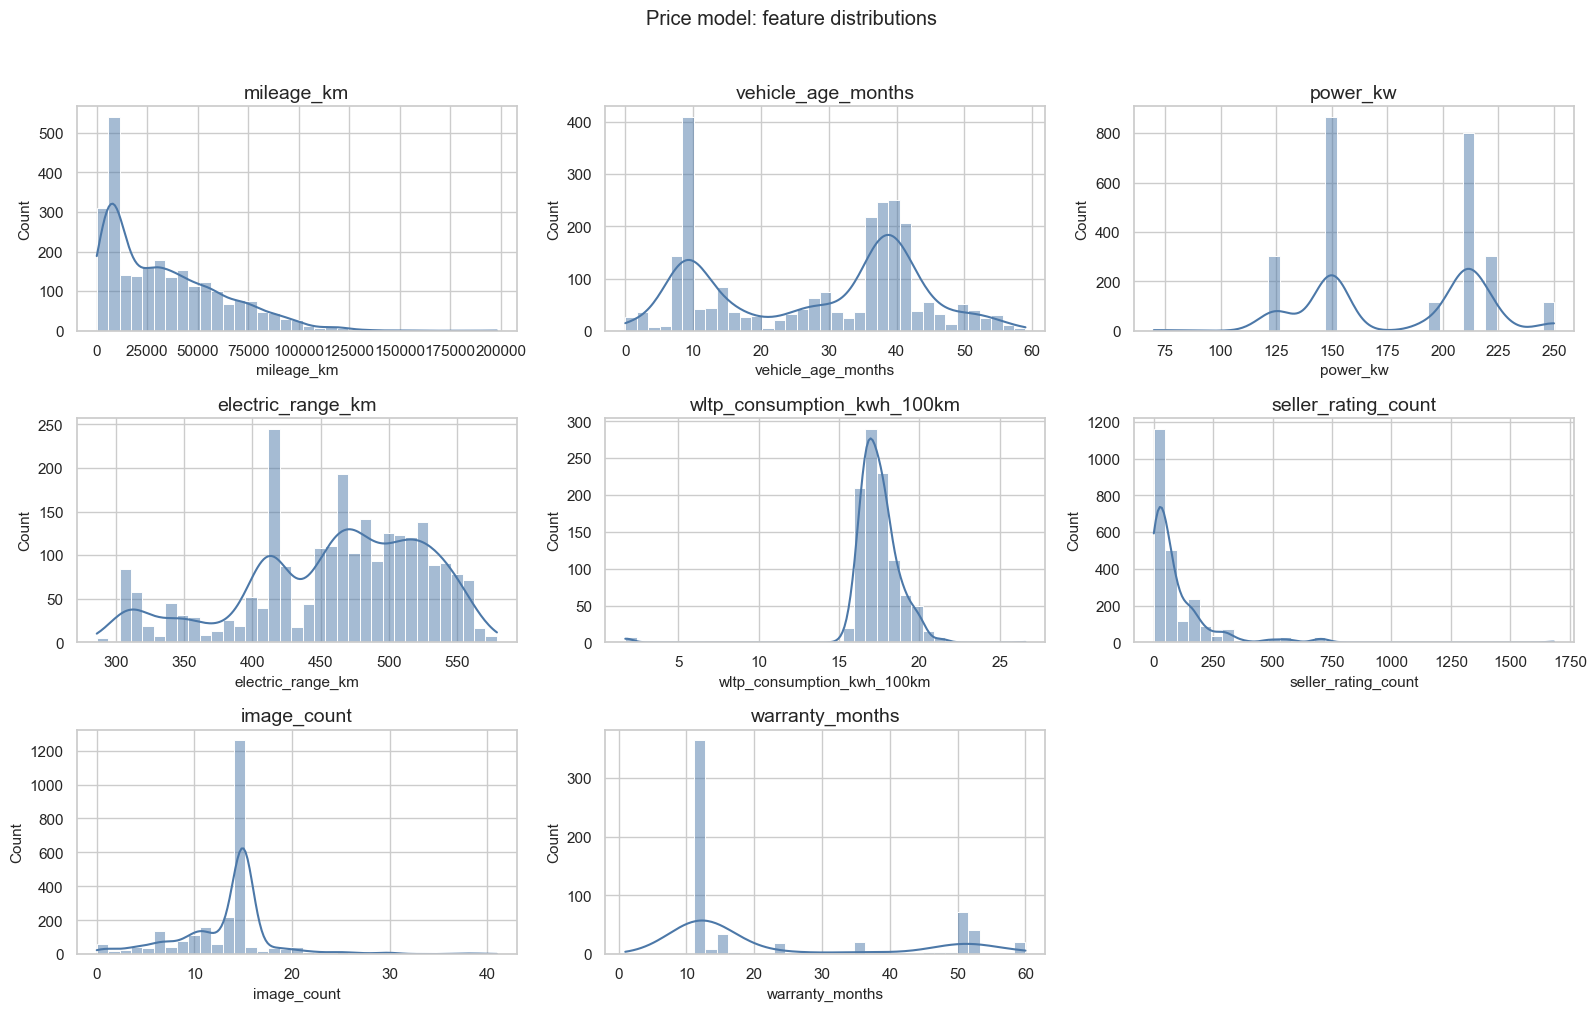

### Price correlations including leakage columns

,spearman_corr,abs_corr,non_null_pairs,missing_pct
vehicle_age_months,-0.795,0.795,2446,2.782
price_per_range_km,0.785,0.785,2440,3.021
mileage_km,-0.770,0.770,2513,0.119
warranty_months,0.656,0.656,604,75.994
power_kw,0.638,0.638,2513,0.119
power_hp,0.638,0.638,2513,0.119
price_per_kw,0.516,0.516,2513,0.119
price_per_hp,0.514,0.514,2513,0.119
electric_range_km,0.388,0.388,2439,3.060
mileage_per_month,-0.361,0.361,2445,2.822


### Price correlations excluding target-derived leakage columns

,spearman_corr,abs_corr,non_null_pairs,missing_pct
vehicle_age_months,-0.795,0.795,2446,2.782
mileage_km,-0.770,0.770,2513,0.119
warranty_months,0.656,0.656,604,75.994
power_kw,0.638,0.638,2513,0.119
power_hp,0.638,0.638,2513,0.119
electric_range_km,0.388,0.388,2439,3.060
mileage_per_month,-0.361,0.361,2445,2.822
has_ahk,0.252,0.252,2516,0.000
is_s_line,0.180,0.180,2516,0.000
is_quattro,0.171,0.171,2516,0.000


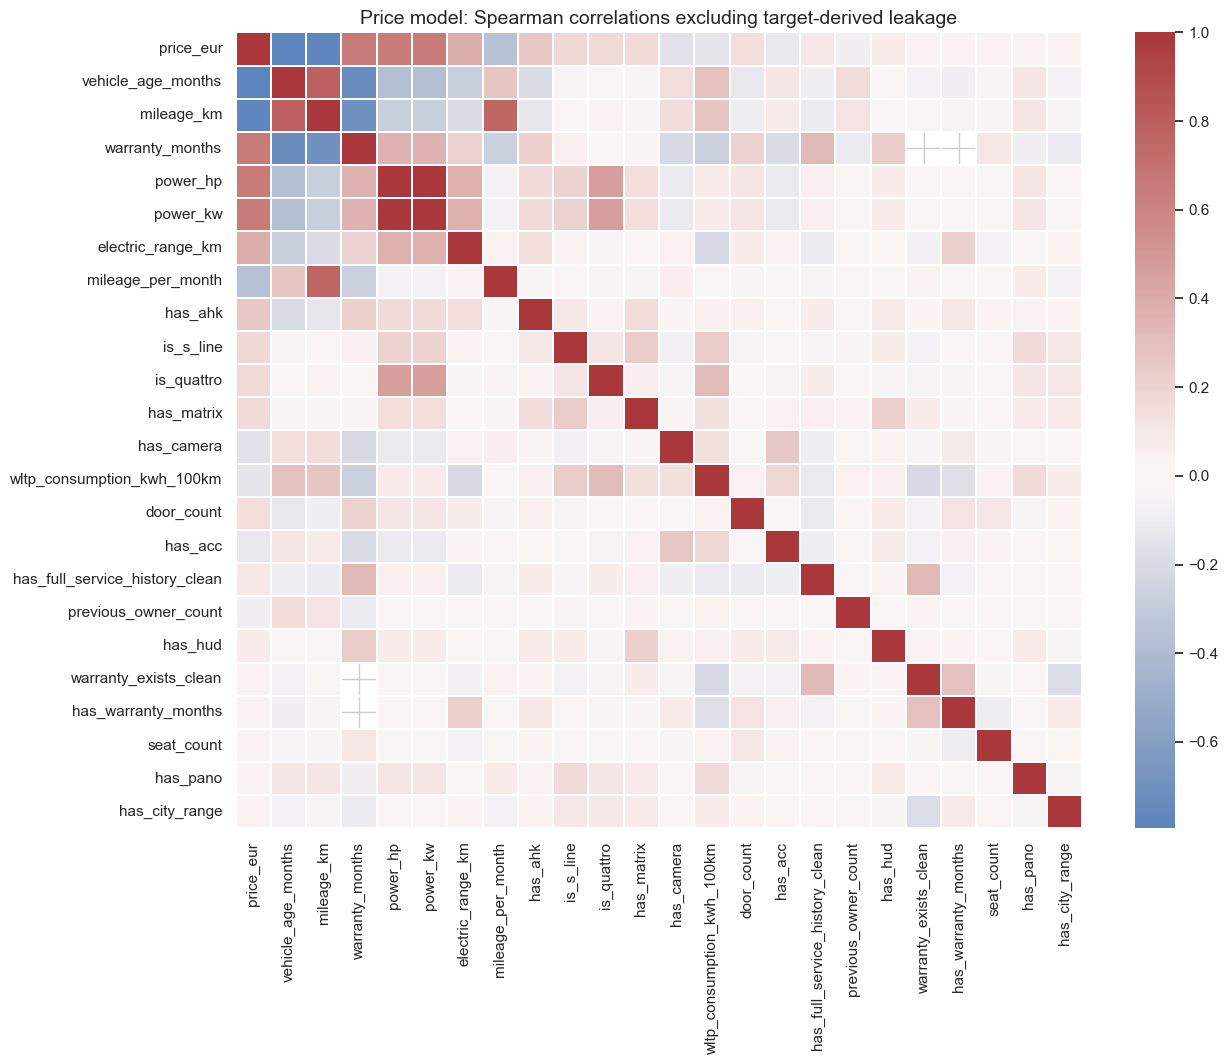

### Categorical associations with price

,feature,eta,target_spread,unique_count,non_null_rows,missing_pct
1,model_number_v2,0.737,"22,682.500",5,2272,9.698
7,upholstery_material,0.261,"18,761.000",6,2433,3.299
16,has_ahk,0.230,"8,410.000",2,2516,0.000
4,exterior_color,0.186,"24,516.000",7,2467,1.948
12,is_quattro,0.168,"3,109.500",2,2516,0.000
19,has_camera,0.165,"4,339.500",2,2516,0.000
13,is_s_line,0.150,"3,995.000",2,2516,0.000
14,has_matrix,0.133,"4,425.000",2,2516,0.000
18,has_acc,0.123,"3,681.500",2,2516,0.000
10,has_full_service_history_clean,0.090,"3,510.000",2,2478,1.510


**Median price by model_number_v2**

,count,mean,median,std
model_number_v2,,,,
55.0,100,"50,806.520","49,567.500","6,074.940"
45.0,830,"45,792.064","45,609.500","7,652.026"
<Missing>,244,"41,199.324","40,040.000","11,495.115"
50.0,285,"36,395.870","36,520.000","4,850.865"
40.0,783,"33,551.052","32,440.000","6,074.604"
35.0,274,"27,852.040","26,885.000","4,479.040"


**Median price by variant**

...

,count,mean,median,std
paint_type,,,,
Metallic,1859,"39,393.727","37,980.000","9,731.133"
Others,303,"36,916.267","35,840.000","9,631.308"
<Missing>,354,"36,714.373","33,980.000","9,303.124"


**Median price by upholstery_material**

,count,mean,median,std
upholstery_material,,,,
Alcantara,58,"46,252.741","47,690.000","10,586.844"
Full leather,399,"41,644.832","40,450.000","9,585.319"
Part leather,430,"41,658.142","38,895.000","10,617.539"
Other,43,"36,562.140","36,250.000","8,518.578"
<Missing>,83,"37,500.096","34,990.000","10,424.091"
Cloth,1500,"36,955.300","34,980.000","8,901.067"


**Median price by city**

,count,mean,median,std
city,,,,
Singen,28,"50,568.179","54,757.000","13,093.904"
Dortmund,23,"44,757.739","48,470.000","10,157.832"
Eching,88,"45,945.807","46,121.000","5,002.662"
Bergheim,26,"44,929.231","45,870.000","5,991.503"
Gersthofen,34,"43,499.412","45,730.000","8,860.709"
Schweinfurt,47,"45,293.830","44,740.000","7,040.976"
Kitzingen,22,"43,061.818","44,480.000","4,304.774"
Neumarkt,33,"43,741.818","43,980.000","4,408.033"
Hofheim,35,"41,037.971","42,990.000","7,901.508"


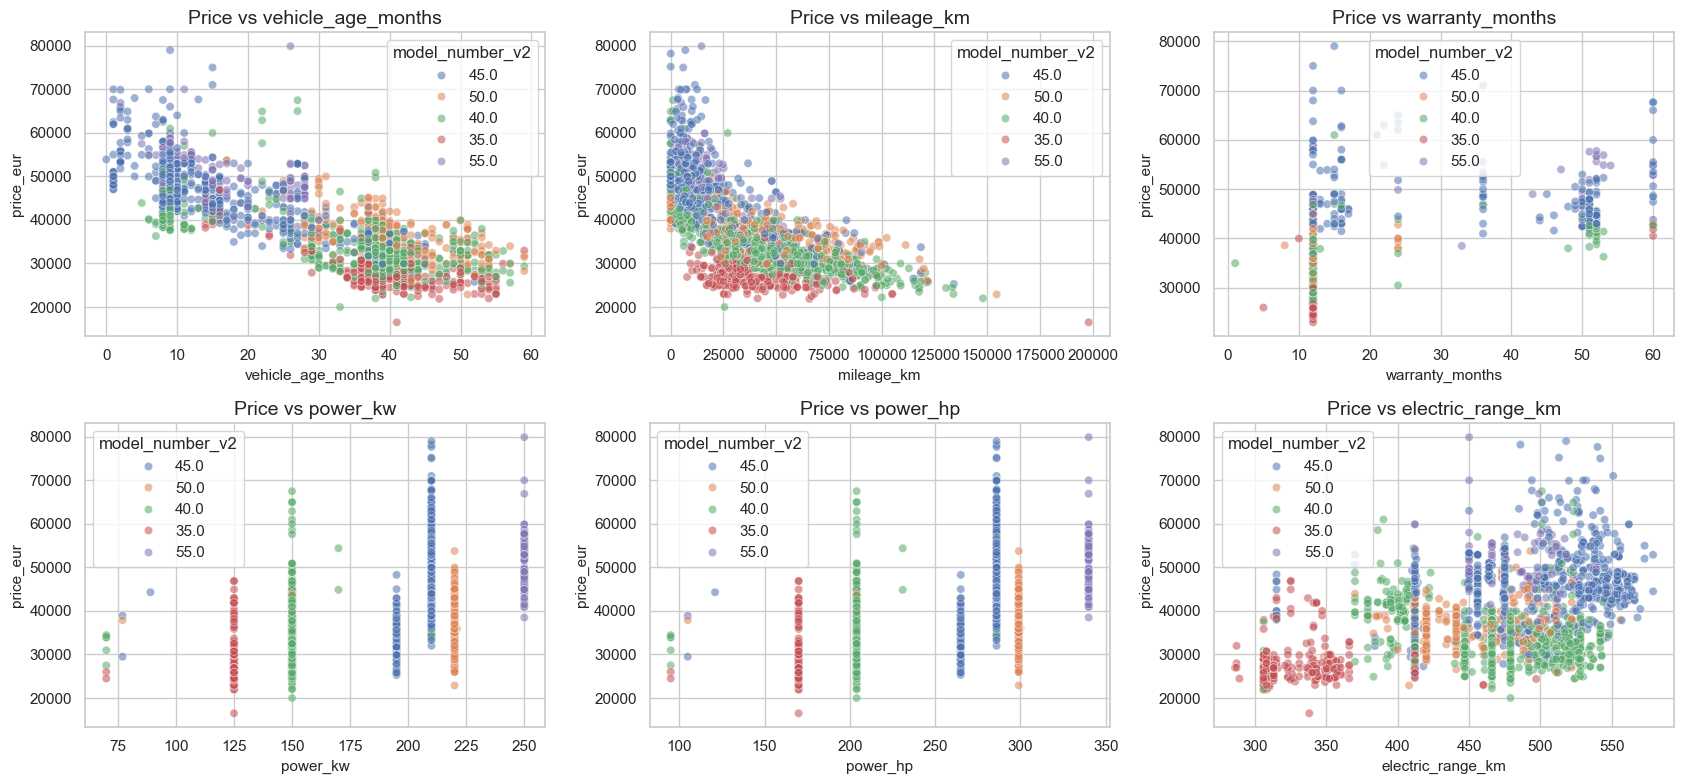

In [17]:
price_target = "price_eur"
price_leakage = [column for column in PRICE_TARGET_LEAKAGE_FEATURES if column in price_df.columns]
price_features_no_leak = price_df.drop(columns=price_leakage, errors="ignore")

display_section("Price target distribution", level=3)
display(price_df[price_target].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).to_frame())

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.histplot(price_df[price_target], bins=45, kde=True, ax=axes[0], color="#4C78A8")
axes[0].set_title("Price distribution")
sns.boxplot(x=price_df[price_target], ax=axes[1], color="#F28E2B")
axes[1].set_title("Price outliers")
plt.tight_layout()
plt.show()

plot_numeric_histograms(
    price_df,
    ["mileage_km", "vehicle_age_months", "power_kw", "electric_range_km", "wltp_consumption_kwh_100km", "seller_rating_count", "image_count", "warranty_months"],
    "Price model: feature distributions",
)

display_section("Price correlations including leakage columns", level=3)
display(numeric_target_correlation(price_df, price_target, method="spearman").head(25))

display_section("Price correlations excluding target-derived leakage columns", level=3)
price_corr_no_leak = numeric_target_correlation(price_features_no_leak, price_target, method="spearman")
display(price_corr_no_leak.head(30))
plot_corr_heatmap(price_features_no_leak, "Price model: Spearman correlations excluding target-derived leakage", target=price_target, max_columns=24)

display_section("Categorical associations with price", level=3)
price_cat_assoc = categorical_association_table(price_features_no_leak, price_target, max_unique=80, min_count=30)
display(price_cat_assoc.head(30))

for category in ["model_number_v2", "variant", "seller_type", "body_type", "exterior_color", "paint_type", "upholstery_material", "city"]:
    if category in price_features_no_leak.columns:
        display(Markdown(f"**Median price by {category}**"))
        display(grouped_target_summary(price_features_no_leak, category, price_target, binary=False, min_count=20, top_n=25))

scatter_columns = price_corr_no_leak.head(6).index.tolist()
scatter_columns = [column for column in scatter_columns if column in price_features_no_leak.columns]
if scatter_columns:
    ncols = 3
    nrows = math.ceil(len(scatter_columns) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(17, max(4, nrows * 4)))
    axes = np.array(axes).reshape(-1)
    for ax, column in zip(axes, scatter_columns):
        sns.scatterplot(data=price_features_no_leak, x=column, y=price_target, hue="model_number_v2" if "model_number_v2" in price_features_no_leak.columns else None, alpha=0.55, ax=ax)
        ax.set_title(f"Price vs {column}")
    for ax in axes[len(scatter_columns):]:
        ax.axis("off")
    plt.tight_layout()
    plt.show()

## Sale 14-Day Model Dataset EDA

This dataset is for predicting whether a listing is sold/removed within 14 days among eligible rows. Price is allowed here because asking price is known at decision time.

### 14-day sale target balance

,count,pct
sold_within_14d,,
1.000,978,50.051
0.000,976,49.949


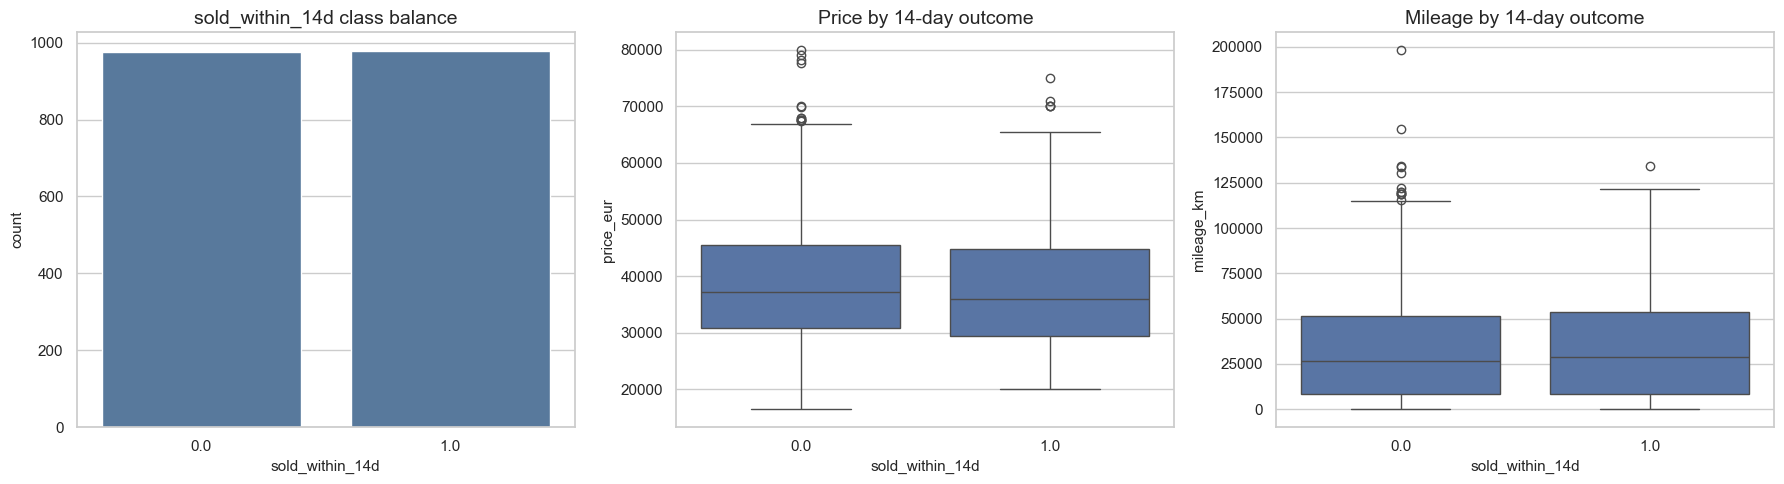

**14-day sale rate by price_band**

,count,target_rate,median,std
price_band,,,,
"(16489.999, 28930.0]",394,0.553,1.000,0.498
"(33880.0, 39990.0]",390,0.503,1.000,0.501
"(39990.0, 46480.0]",387,0.494,0.000,0.501
"(28930.0, 33880.0]",393,0.491,0.000,0.501
"(46480.0, 79900.0]",390,0.462,0.000,0.499


**14-day sale rate by mileage_band**

,count,target_rate,median,std
mileage_band,,,,
"(36245.0, 58600.0]",390,0.523,1.000,0.500
"(58600.0, 198108.0]",390,0.508,1.000,0.501
"(-0.001, 7797.0]",391,0.496,0.000,0.501
"(18276.0, 36245.0]",390,0.490,0.000,0.501
"(7797.0, 18276.0]",390,0.487,0.000,0.500


**14-day sale rate by age_band**

...

,count,target_rate,median,std
exterior_color,,,,
<Missing>,47,0.660,1.000,0.479
Grey,713,0.520,1.000,0.500
Black,471,0.486,0.000,0.500
Blue,326,0.482,0.000,0.500
White,258,0.481,0.000,0.501
Violet,71,0.479,0.000,0.503
Silver,68,0.471,0.000,0.503


**14-day sale rate by city**

,count,target_rate,median,std
city,,,,
Neumarkt,20,0.900,1.000,0.308
Eching,54,0.778,1.000,0.420
Hamburg,38,0.763,1.000,0.431
Frankfurt am Main,25,0.720,1.000,0.458
Hofheim,28,0.643,1.000,0.488
Gersthofen,27,0.630,1.000,0.492
München,23,0.522,1.000,0.511
Schweinfurt,33,0.515,1.000,0.508
Hannover,24,0.500,0.500,0.511


### Numeric correlations with sold_within_14d

,spearman_corr,abs_corr,non_null_pairs,missing_pct
price_per_hp,-0.126,0.126,1953,0.051
battery_charging_time_min,-0.126,0.126,114,94.166
price_per_kw,-0.126,0.126,1953,0.051
has_city_range,-0.086,0.086,1954,0.000
price_eur,-0.060,0.060,1954,0.000
price_per_range_km,-0.057,0.057,1882,3.685
previous_owner_count,-0.056,0.056,1859,4.862
has_acc,-0.049,0.049,1954,0.000
has_charging_time,-0.048,0.048,1954,0.000
power_hp,0.047,0.047,1953,0.051


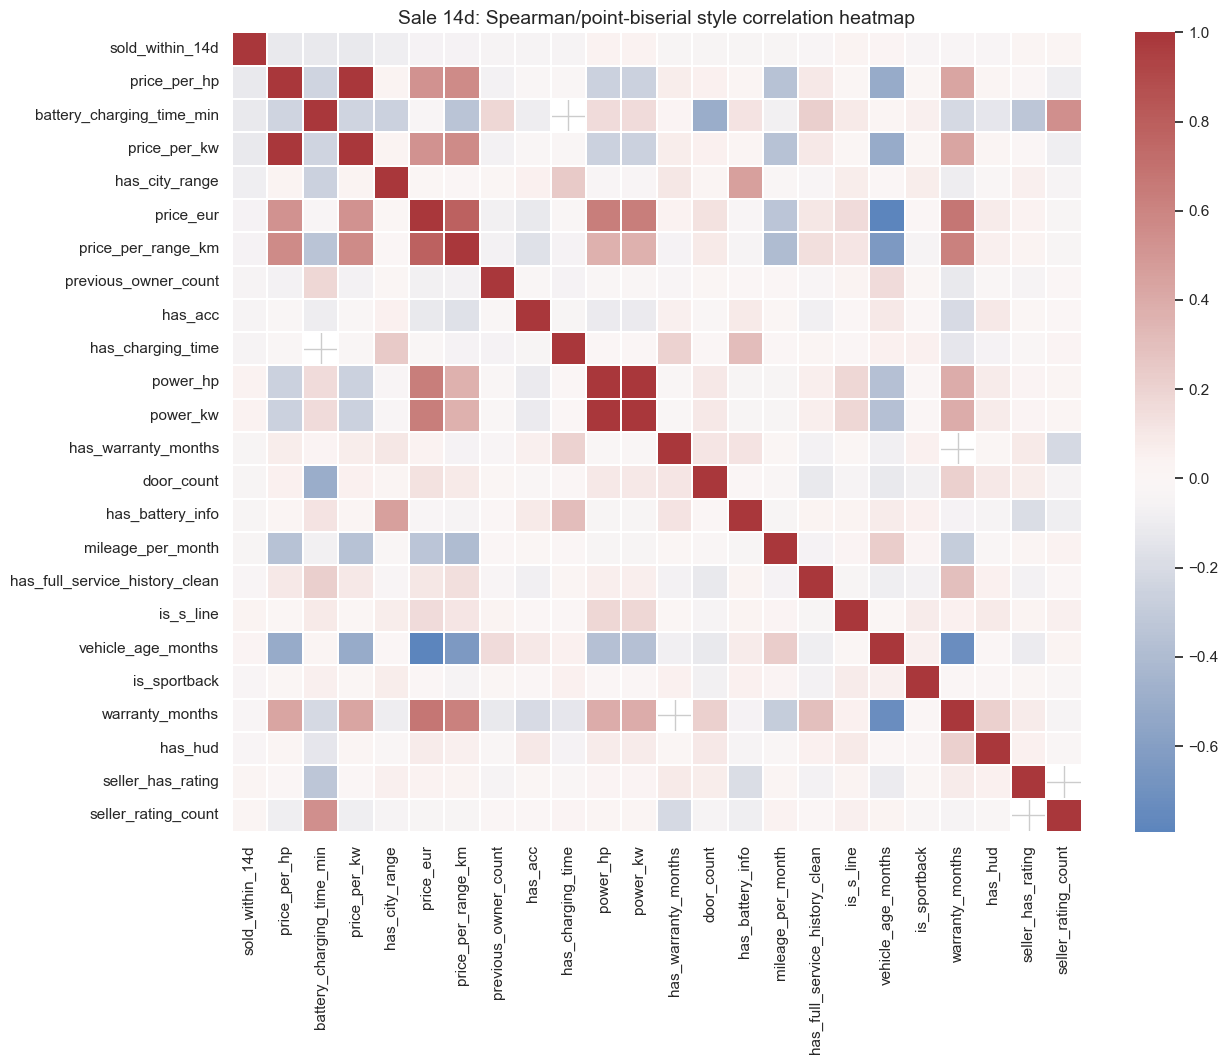

### Categorical associations with sold_within_14d

,feature,cramers_v,target_spread,unique_count,non_null_rows,missing_pct
20,duplicate_listing_id,0.187,0.327,2,1954,0.000
24,has_city_range,0.083,0.212,2,1954,0.000
2,seller_type,0.055,0.215,2,1954,0.000
7,upholstery_material,0.052,0.373,6,1877,3.941
18,has_acc,0.043,0.059,2,1954,0.000
25,has_charging_time,0.043,0.103,2,1954,0.000
22,has_warranty_months,0.036,0.049,2,1954,0.000
23,has_battery_info,0.035,0.080,2,1954,0.000
10,has_full_service_history_clean,0.028,0.047,2,1916,1.945
13,is_s_line,0.027,0.038,2,1954,0.000


,target_0.0,target_1.0,median_diff_1_minus_0
price_eur,"37,170.000","35,985.000","-1,185.000"
mileage_km,"26,735.000","29,055.000","2,320.000"
vehicle_age_months,34.000,37.000,3.000
power_kw,195.000,195.000,0.000
electric_range_km,475.000,466.000,-9.000
seller_rating_count,44.000,50.000,6.000
image_count,15.000,15.000,0.000


In [18]:
sale_target = "sold_within_14d"
sale_df[sale_target] = pd.to_numeric(sale_df[sale_target], errors="coerce")

display_section("14-day sale target balance", level=3)
sale_balance = sale_df[sale_target].value_counts(dropna=False).to_frame("count")
sale_balance["pct"] = sale_balance["count"] / len(sale_df) * 100
display(sale_balance)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.countplot(data=sale_df, x=sale_target, ax=axes[0], color="#4C78A8")
axes[0].set_title("sold_within_14d class balance")
sns.boxplot(data=sale_df, x=sale_target, y="price_eur", ax=axes[1])
axes[1].set_title("Price by 14-day outcome")
sns.boxplot(data=sale_df, x=sale_target, y="mileage_km", ax=axes[2])
axes[2].set_title("Mileage by 14-day outcome")
plt.tight_layout()
plt.show()

sale_segment_df = sale_df.copy()
sale_segment_df["price_band"] = safe_qcut(sale_segment_df["price_eur"], q=5)
sale_segment_df["mileage_band"] = safe_qcut(sale_segment_df["mileage_km"], q=5)
sale_segment_df["age_band"] = safe_qcut(sale_segment_df["vehicle_age_months"], q=5)
sale_segment_df["power_band"] = safe_qcut(sale_segment_df["power_kw"], q=4)

for category in ["price_band", "mileage_band", "age_band", "power_band", "model_number_v2", "variant", "seller_type", "body_type", "exterior_color", "city"]:
    if category in sale_segment_df.columns:
        display(Markdown(f"**14-day sale rate by {category}**"))
        display(grouped_target_summary(sale_segment_df, category, sale_target, binary=True, min_count=20, top_n=30))

display_section("Numeric correlations with sold_within_14d", level=3)
sale_corr = numeric_target_correlation(sale_df, sale_target, method="spearman")
display(sale_corr.head(35))
plot_corr_heatmap(sale_df, "Sale 14d: Spearman/point-biserial style correlation heatmap", target=sale_target, max_columns=24)

display_section("Categorical associations with sold_within_14d", level=3)
sale_cat_assoc = categorical_association_table(sale_df, sale_target, max_unique=80, min_count=30)
display(sale_cat_assoc.head(35))

numeric_compare_cols = ["price_eur", "mileage_km", "vehicle_age_months", "power_kw", "electric_range_km", "seller_rating_count", "image_count"]
numeric_compare_cols = [column for column in numeric_compare_cols if column in sale_df.columns]
comparison = sale_df.groupby(sale_target)[numeric_compare_cols].median().T
comparison.columns = [f"target_{column}" for column in comparison.columns]
if comparison.shape[1] == 2:
    comparison["median_diff_1_minus_0"] = comparison.iloc[:, 1] - comparison.iloc[:, 0]
display(comparison)

## Survival / Time-To-Sell Dataset EDA

This dataset supports time-to-event modeling. `duration_days` is observed lifetime; `event_sold_or_removed` indicates whether the listing disappeared versus being censored at the last scrape.

### Survival target summary

,duration_days,event_sold_or_removed,price_eur,mileage_km,vehicle_age_months
count,"2,516.000","2,516.000","2,516.000","2,513.000","2,446.000"
mean,11.248,0.457,"38,718.385","33,261.798",28.206
std,7.615,0.498,"9,723.052","28,445.523",15.030
min,0.000,0.000,"16,490.000",0.000,0.000
5%,1.000,0.000,"25,717.500","2,472.400",8.000
25%,5.000,0.000,"30,480.000","8,100.000",10.000
50%,10.000,0.000,"37,500.000","26,974.000",36.000
75%,21.000,1.000,"45,480.000","51,655.000",39.000
95%,21.000,1.000,"55,391.500","88,500.000",50.000
max,21.000,1.000,"79,900.000","198,108.000",59.000


,count,pct
event_sold_or_removed,,
0,1365,54.253
1,1151,45.747


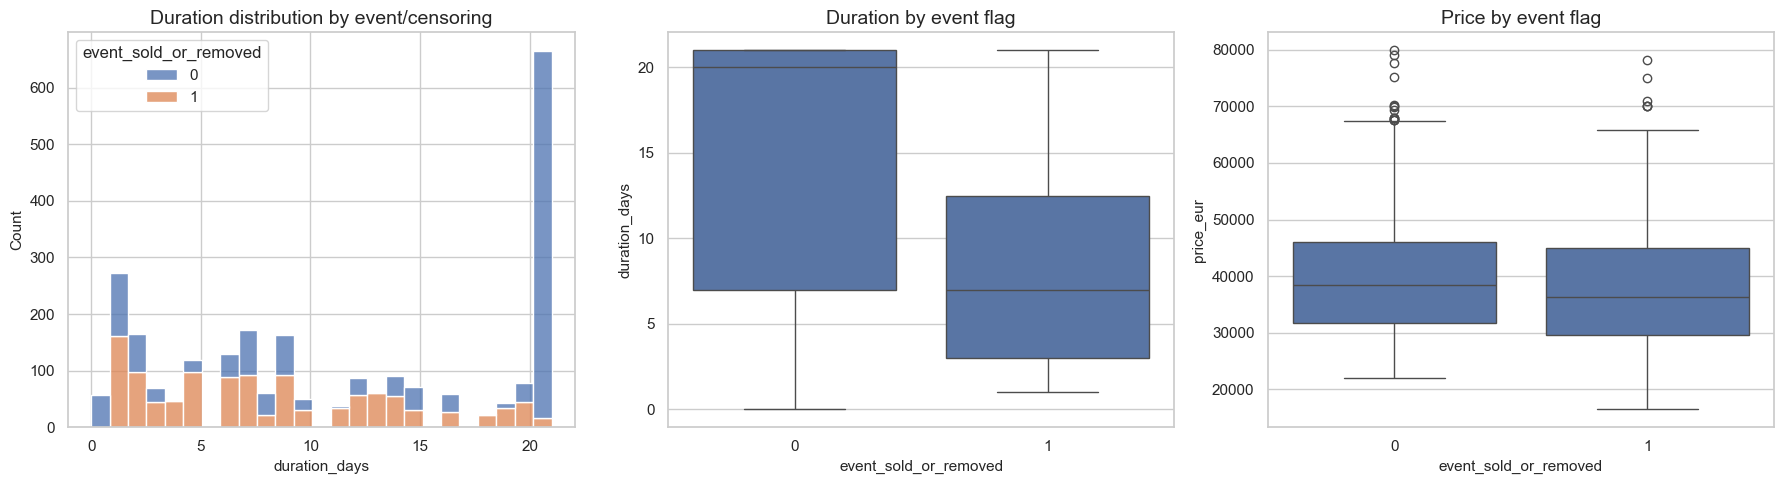

### Overall Kaplan-Meier style table

,duration_days,at_risk,events,censored,survival_probability,sold_or_removed_probability
0,1.000,2460,162,110,0.934,0.066
1,2.000,2188,97,67,0.893,0.107
2,3.000,2024,45,25,0.873,0.127
3,4.000,1954,47,0,0.852,0.148
4,5.000,1907,98,20,0.808,0.192
5,6.000,1789,89,40,0.768,0.232
6,7.000,1660,92,80,0.725,0.275
7,8.000,1488,21,39,0.715,0.285
8,9.000,1428,92,71,0.669,0.331
9,10.000,1265,31,19,0.653,0.347


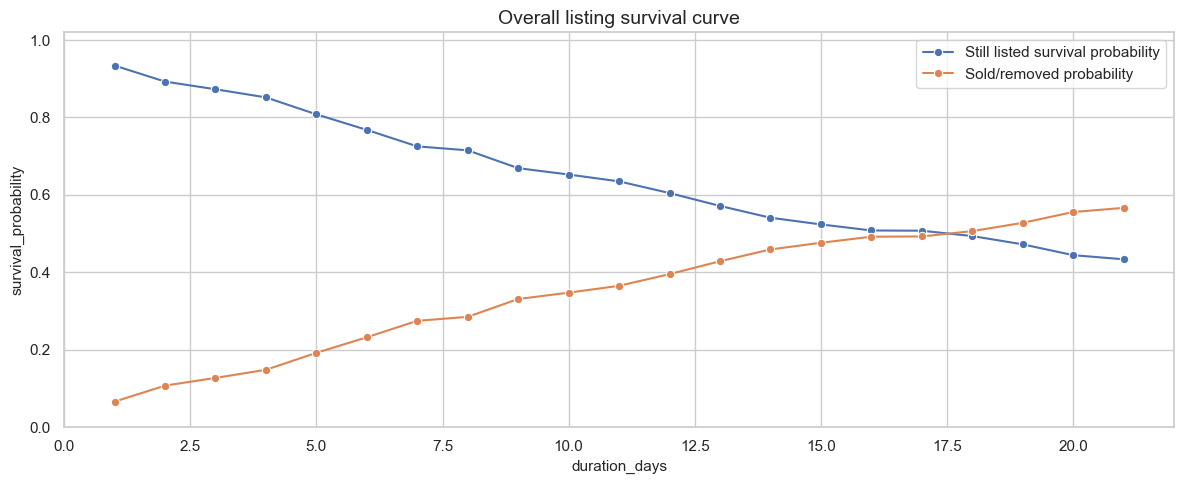

**Duration and event rate by price_band**

,count,median_duration_days,mean_duration_days,event_rate,median_price
_category,,,,,
"(16489.999, 30480.0]",636,9.000,11.182,0.538,"27,895.000"
"(45480.0, 79900.0]",628,9.000,10.997,0.414,"49,567.500"
"(37500.0, 45480.0]",629,10.000,11.099,0.436,"41,990.000"
"(30480.0, 37500.0]",623,11.000,11.717,0.441,"33,930.000"


**Duration and event rate by mileage_band**

,count,median_duration_days,mean_duration_days,event_rate,median_price
_category,,,,,
"(-0.001, 8100.0]",631,9.000,10.520,0.410,"46,821.000"
"(51655.0, 198108.0]",628,9.000,11.272,0.482,"29,880.000"
"(8100.0, 26974.0]",627,11.000,11.582,0.459,"43,840.000"
"(26974.0, 51655.0]",627,12.000,11.587,0.478,"32,980.000"


**Duration and event rate by age_band**

...

,count,median_duration_days,mean_duration_days,event_rate,median_price
_category,,,,,
Q4 e-tron,1655,9.000,11.045,0.459,"37,890.000"
Q4 e-tron Sportback,848,11.500,11.767,0.447,"36,879.500"


**Duration and event rate by seller_type**

,count,median_duration_days,mean_duration_days,event_rate,median_price
_category,,,,,
Dealer,2473,9.000,11.167,0.459,"37,700.000"
PrivateSeller,43,21.000,15.907,0.372,"35,300.000"


### Numeric correlations with duration_days

,spearman_corr,abs_corr,non_null_pairs,missing_pct
event_sold_or_removed,-0.373,0.373,2516,0.000
battery_charging_time_min,0.126,0.126,140,94.436
previous_owner_count,0.066,0.066,2378,5.485
has_city_range,0.061,0.061,2516,0.000
vehicle_age_months,0.059,0.059,2446,2.782
has_hud,0.056,0.056,2516,0.000
has_acc,0.055,0.055,2516,0.000
warranty_exists_clean,-0.054,0.054,2479,1.471
wltp_consumption_kwh_100km,0.053,0.053,1008,59.936
is_sportback,0.050,0.050,2516,0.000


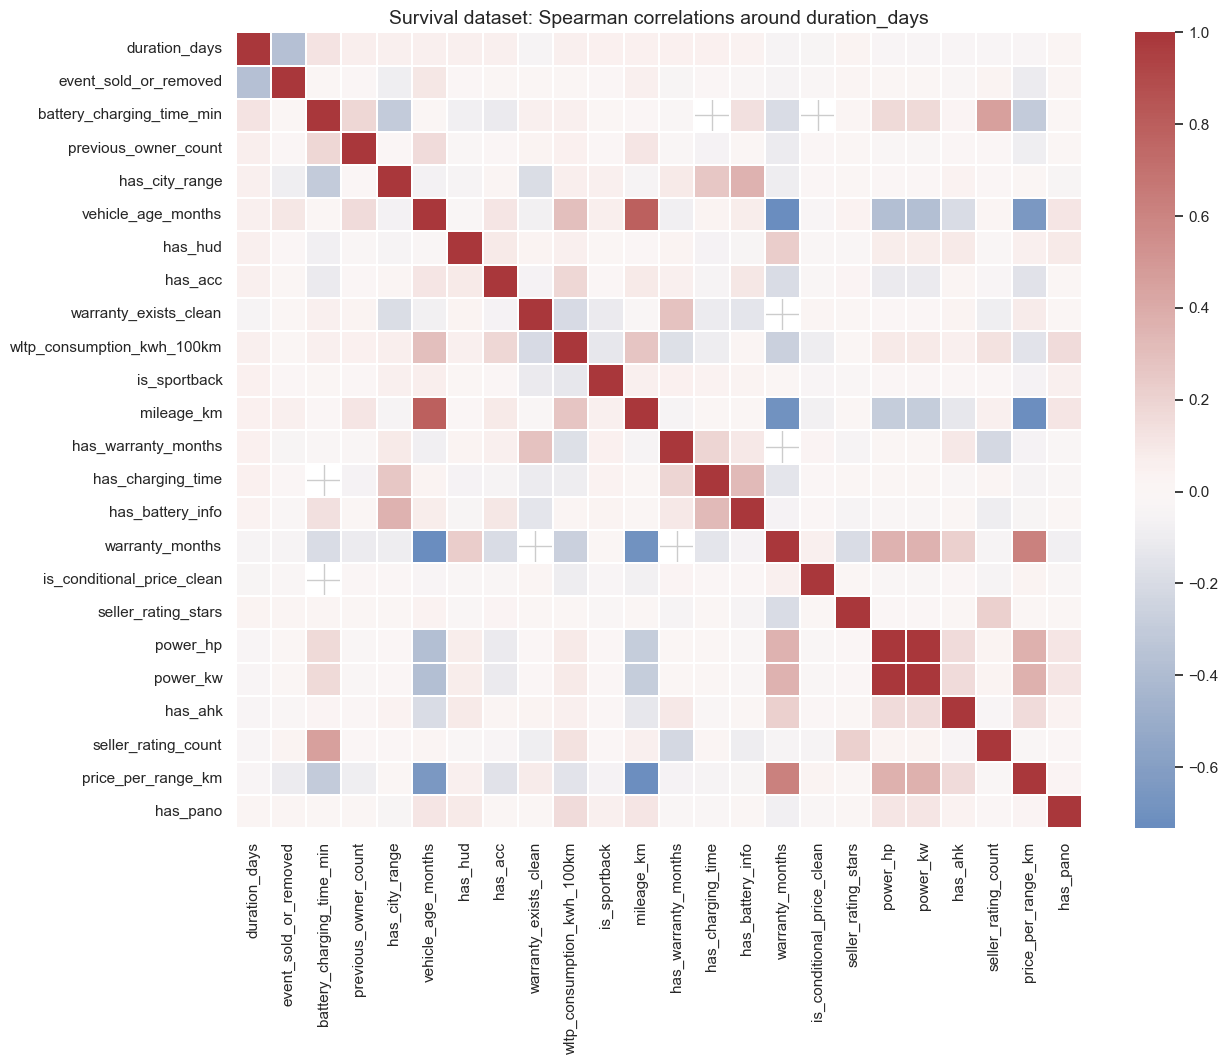

### Numeric correlations with event_sold_or_removed

,spearman_corr,abs_corr,non_null_pairs,missing_pct
duration_days,-0.373,0.373,2516,0.000
price_per_hp,-0.145,0.145,2513,0.119
price_per_kw,-0.145,0.145,2513,0.119
price_per_range_km,-0.107,0.107,2440,3.021
vehicle_age_months,0.100,0.100,2446,2.782
price_eur,-0.097,0.097,2516,0.000
has_city_range,-0.088,0.088,2516,0.000
mileage_km,0.056,0.056,2513,0.119
warranty_months,-0.045,0.045,604,75.994
has_warranty_months,-0.038,0.038,2516,0.000


### Categorical associations with event_sold_or_removed

,feature,cramers_v,target_spread,unique_count,non_null_rows,missing_pct
20,duplicate_listing_id,0.109,0.185,2,2516,0.000
24,has_city_range,0.086,0.207,2,2516,0.000
7,upholstery_material,0.063,0.364,6,2433,3.299
5,paint_type,0.042,0.068,2,2162,14.070
22,has_warranty_months,0.032,0.044,2,2516,0.000
21,seller_has_rating,0.025,0.061,2,2516,0.000
6,interior_color,0.024,0.571,7,2429,3.458
1,model_number_v2,0.022,0.078,5,2272,9.698
10,has_full_service_history_clean,0.022,0.039,2,2478,1.510
8,is_conditional_price_clean,0.020,0.292,2,2516,0.000


In [19]:
duration_target = "duration_days"
event_target = "event_sold_or_removed"
survival_df[duration_target] = pd.to_numeric(survival_df[duration_target], errors="coerce")
survival_df[event_target] = pd.to_numeric(survival_df[event_target], errors="coerce")

display_section("Survival target summary", level=3)
display(survival_df[[duration_target, event_target, "price_eur", "mileage_km", "vehicle_age_months"]].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]))

event_balance = survival_df[event_target].value_counts(dropna=False).to_frame("count")
event_balance["pct"] = event_balance["count"] / len(survival_df) * 100
display(event_balance)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(data=survival_df, x=duration_target, hue=event_target, bins=25, multiple="stack", ax=axes[0])
axes[0].set_title("Duration distribution by event/censoring")
sns.boxplot(data=survival_df, x=event_target, y=duration_target, ax=axes[1])
axes[1].set_title("Duration by event flag")
sns.boxplot(data=survival_df, x=event_target, y="price_eur", ax=axes[2])
axes[2].set_title("Price by event flag")
plt.tight_layout()
plt.show()

km_overall = kaplan_meier_table(survival_df, duration_target, event_target)
display_section("Overall Kaplan-Meier style table", level=3)
display(km_overall)

if len(km_overall):
    plt.figure(figsize=(12, 5))
    sns.lineplot(data=km_overall, x="duration_days", y="survival_probability", marker="o", label="Still listed survival probability")
    sns.lineplot(data=km_overall, x="duration_days", y="sold_or_removed_probability", marker="o", label="Sold/removed probability")
    plt.title("Overall listing survival curve")
    plt.ylim(0, 1.02)
    plt.tight_layout()
    plt.show()

survival_segment_df = survival_df.copy()
survival_segment_df["price_band"] = safe_qcut(survival_segment_df["price_eur"], q=4)
survival_segment_df["mileage_band"] = safe_qcut(survival_segment_df["mileage_km"], q=4)
survival_segment_df["age_band"] = safe_qcut(survival_segment_df["vehicle_age_months"], q=4)

for category in ["price_band", "mileage_band", "age_band", "model_number_v2", "variant", "seller_type"]:
    if category in survival_segment_df.columns:
        display(Markdown(f"**Duration and event rate by {category}**"))
        summary = (
            survival_segment_df.assign(_category=survival_segment_df[category].astype("string").fillna("<Missing>"))
            .groupby("_category")
            .agg(
                count=(duration_target, "size"),
                median_duration_days=(duration_target, "median"),
                mean_duration_days=(duration_target, "mean"),
                event_rate=(event_target, "mean"),
                median_price=("price_eur", "median"),
            )
            .query("count >= 20")
            .sort_values("median_duration_days")
        )
        display(summary.head(30))

display_section("Numeric correlations with duration_days", level=3)
display(numeric_target_correlation(survival_df, duration_target, method="spearman").head(35))
plot_corr_heatmap(survival_df, "Survival dataset: Spearman correlations around duration_days", target=duration_target, max_columns=24)

display_section("Numeric correlations with event_sold_or_removed", level=3)
display(numeric_target_correlation(survival_df, event_target, method="spearman").head(35))

display_section("Categorical associations with event_sold_or_removed", level=3)
display(categorical_association_table(survival_df, event_target, max_unique=80, min_count=30).head(35))

## Cross-Dataset Target And Correlation Summary

This compact comparison shows which variables are most associated with each target across the three ML datasets.

In [20]:
target_specs = {
    "price_model": {"target": "price_eur", "exclude": PRICE_TARGET_LEAKAGE_FEATURES},
    "sale_14d": {"target": "sold_within_14d", "exclude": []},
    "survival_duration": {"dataset": "survival", "target": "duration_days", "exclude": []},
    "survival_event": {"dataset": "survival", "target": "event_sold_or_removed", "exclude": []},
}

summary_tables = {}
for label, spec in target_specs.items():
    dataset_name = spec.get("dataset", label)
    data = datasets[dataset_name]
    target = spec["target"]
    exclude = spec.get("exclude", [])

    numeric_table = numeric_target_correlation(data, target, method="spearman", exclude=exclude).head(15)
    categorical_table = categorical_association_table(data, target, max_unique=80, min_count=30).head(15)

    summary_tables[f"{label}_numeric"] = numeric_table
    summary_tables[f"{label}_categorical"] = categorical_table

    display_section(f"{label}: top numeric correlations with {target}", level=3)
    display(numeric_table)
    display_section(f"{label}: top categorical associations with {target}", level=3)
    display(categorical_table)

# Build a side-by-side numeric association comparison for common numeric features.
comparison_frames = []
for label, spec in target_specs.items():
    dataset_name = spec.get("dataset", label)
    data = datasets[dataset_name]
    target = spec["target"]
    exclude = spec.get("exclude", [])
    table = numeric_target_correlation(data, target, method="spearman", exclude=exclude)
    corr_col = "spearman_corr"
    temp = table[[corr_col]].rename(columns={corr_col: label})
    comparison_frames.append(temp)

numeric_target_comparison = pd.concat(comparison_frames, axis=1).sort_index()
numeric_target_comparison["max_abs_corr"] = numeric_target_comparison.abs().max(axis=1)
numeric_target_comparison = numeric_target_comparison.sort_values("max_abs_corr", ascending=False)
display_section("Cross-target numeric association comparison", level=3)
display(numeric_target_comparison.head(40))

### price_model: top numeric correlations with price_eur

,spearman_corr,abs_corr,non_null_pairs,missing_pct
vehicle_age_months,-0.795,0.795,2446,2.782
mileage_km,-0.770,0.770,2513,0.119
warranty_months,0.656,0.656,604,75.994
power_kw,0.638,0.638,2513,0.119
power_hp,0.638,0.638,2513,0.119
electric_range_km,0.388,0.388,2439,3.060
mileage_per_month,-0.361,0.361,2445,2.822
has_ahk,0.252,0.252,2516,0.000
is_s_line,0.180,0.180,2516,0.000
is_quattro,0.171,0.171,2516,0.000


### price_model: top categorical associations with price_eur

,feature,eta,target_spread,unique_count,non_null_rows,missing_pct
1,model_number_v2,0.737,"22,682.500",5,2272,9.698
7,upholstery_material,0.261,"18,761.000",6,2433,3.299
16,has_ahk,0.230,"8,410.000",2,2516,0.000
4,exterior_color,0.186,"24,516.000",7,2467,1.948
12,is_quattro,0.168,"3,109.500",2,2516,0.000
19,has_camera,0.165,"4,339.500",2,2516,0.000
13,is_s_line,0.150,"3,995.000",2,2516,0.000
14,has_matrix,0.133,"4,425.000",2,2516,0.000
18,has_acc,0.123,"3,681.500",2,2516,0.000
10,has_full_service_history_clean,0.090,"3,510.000",2,2478,1.510


### sale_14d: top numeric correlations with sold_within_14d

...

,spearman_corr,abs_corr,non_null_pairs,missing_pct
duration_days,-0.373,0.373,2516,0.000
price_per_hp,-0.145,0.145,2513,0.119
price_per_kw,-0.145,0.145,2513,0.119
price_per_range_km,-0.107,0.107,2440,3.021
vehicle_age_months,0.100,0.100,2446,2.782
price_eur,-0.097,0.097,2516,0.000
has_city_range,-0.088,0.088,2516,0.000
mileage_km,0.056,0.056,2513,0.119
warranty_months,-0.045,0.045,604,75.994
has_warranty_months,-0.038,0.038,2516,0.000


### survival_event: top categorical associations with event_sold_or_removed

,feature,cramers_v,target_spread,unique_count,non_null_rows,missing_pct
20,duplicate_listing_id,0.109,0.185,2,2516,0.000
24,has_city_range,0.086,0.207,2,2516,0.000
7,upholstery_material,0.063,0.364,6,2433,3.299
5,paint_type,0.042,0.068,2,2162,14.070
22,has_warranty_months,0.032,0.044,2,2516,0.000
21,seller_has_rating,0.025,0.061,2,2516,0.000
6,interior_color,0.024,0.571,7,2429,3.458
1,model_number_v2,0.022,0.078,5,2272,9.698
10,has_full_service_history_clean,0.022,0.039,2,2478,1.510
8,is_conditional_price_clean,0.020,0.292,2,2516,0.000


### Cross-target numeric association comparison

,price_model,sale_14d,survival_duration,survival_event,max_abs_corr
vehicle_age_months,-0.795,0.034,0.059,0.100,0.795
mileage_km,-0.770,0.021,0.048,0.056,0.770
warranty_months,0.656,-0.031,-0.044,-0.045,0.656
power_kw,0.638,0.047,-0.035,0.018,0.638
power_hp,0.638,0.047,-0.035,0.018,0.638
electric_range_km,0.388,-0.021,0.016,-0.001,0.388
duration_days,NaN,NaN,NaN,-0.373,0.373
event_sold_or_removed,NaN,NaN,-0.373,NaN,0.373
mileage_per_month,-0.361,-0.037,0.014,-0.028,0.361
has_ahk,0.252,0.017,-0.034,-0.017,0.252


## Deal-Oriented Exploratory Diagnostics

This is not a trained model. It is a quick EDA proxy to inspect listings that are cheap relative to comparable cars and belong to segments that move faster. Use this only as an exploration table before model training.

In [21]:
deal_df = lifecycle_df.copy()

if "model_number" in deal_df.columns:
    model_col = "model_number"
elif "model_number_v2" in deal_df.columns:
    model_col = "model_number_v2"
else:
    model_col = None

required_deal_cols = {"price_eur", "mileage_km", "vehicle_age_months", "sold_flag"}
if required_deal_cols.issubset(deal_df.columns) and model_col:
    deal_df["mileage_band"] = safe_qcut(deal_df["mileage_km"], q=5).astype("string")
    deal_df["age_band"] = safe_qcut(deal_df["vehicle_age_months"], q=5).astype("string")
    group_cols = [model_col, "variant", "mileage_band", "age_band"]
    group_cols = [column for column in group_cols if column in deal_df.columns]

    segment_stats = (
        deal_df.groupby(group_cols, dropna=False)
        .agg(
            segment_count=("price_eur", "size"),
            segment_median_price=("price_eur", "median"),
            segment_sold_rate=("sold_flag", "mean"),
        )
        .reset_index()
    )

    deal_df = deal_df.merge(segment_stats, on=group_cols, how="left")
    deal_df["price_vs_segment_median"] = deal_df["price_eur"] - deal_df["segment_median_price"]
    deal_df["discount_vs_segment_median_pct"] = -deal_df["price_vs_segment_median"] / deal_df["segment_median_price"] * 100
    deal_df["eda_deal_score"] = deal_df["discount_vs_segment_median_pct"] * deal_df["segment_sold_rate"]

    candidate_columns = [
        "listing_id", "title", "listing_url", "status", "price_eur", "segment_median_price",
        "discount_vs_segment_median_pct", "segment_sold_rate", "eda_deal_score",
        model_col, "variant", "mileage_km", "vehicle_age_months", "power_kw", "electric_range_km",
        "city", "seller_name",
    ]
    candidate_columns = [column for column in candidate_columns if column in deal_df.columns]

    exploratory_candidates = (
        deal_df[deal_df["segment_count"] >= 10]
        .sort_values("eda_deal_score", ascending=False)
        [candidate_columns]
        .head(40)
    )

    display_section("EDA proxy: potentially underpriced fast-moving segment listings", level=3)
    display(exploratory_candidates)
else:
    print("Required deal diagnostic columns are not available.")

### EDA proxy: potentially underpriced fast-moving segment listings

,listing_id,title,listing_url,status,price_eur,segment_median_price,discount_vs_segment_median_pct,segment_sold_rate,eda_deal_score,model_number,variant,mileage_km,vehicle_age_months,power_kw,electric_range_km,city,seller_name
177,63acf0e6-c273-4caf-a291-561c31b6c0bf,Audi Q4 e-tron 40 Sportback,https://www.autoscout24.com/offers/audi-q4-e-t...,sold_or_removed,20000,"34,840.000",42.595,0.556,23.664,40.0,Q4 e-tron Sportback,"25,542.000",33.000,150.000,479.000,Bochum,Krawczyk Automobile
18,763185b7-105d-4975-a263-b9ad4cbf68cf,"Audi Q4 e-tron Sportback 45 399,-ohne Anzahlun...",https://www.autoscout24.com/offers/audi-q4-e-t...,sold_or_removed,34949,"46,785.000",25.299,0.667,16.866,45.0,Q4 e-tron Sportback,"14,235.000",18.000,210.000,545.000,Horn-Bad Meinberg,Kurt Stricker GmbH & Co. KG
499,5fa74014-99f7-49a8-b004-abfabbf553a2,Audi Q4 e-tron Q4 Sportback 45 e-tron S line,https://www.autoscout24.com/offers/audi-q4-e-t...,sold_or_removed,37879,"46,785.000",19.036,0.667,12.691,45.0,Q4 e-tron Sportback,"10,543.000",18.000,210.000,536.000,Barth,Autohaus Neu GmbH
1070,b4deca47-6051-4e25-8b21-9d7547456f1d,Audi Q4 e-tron Q4 e-tron 40 Sportback Navi SHZ...,https://www.autoscout24.com/offers/audi-q4-e-t...,sold_or_removed,23490,"28,880.000",18.663,0.673,12.555,40.0,Q4 e-tron Sportback,"117,741.000",39.000,150.000,479.000,Fernwald-Steinbach,AutoExpo Deutsche Automarkt GmbH
622,eb436560-c71a-4b2e-8334-0e7380806850,Audi Q4 e-tron,https://www.autoscout24.com/offers/audi-q4-e-t...,sold_or_removed,24580,"28,915.000",14.992,0.812,12.181,<NA>,Q4 e-tron,"49,853.000",53.000,125.000,306.000,Düren,Jacobs automobile Düren
620,b0202742-1e57-4002-a7cd-7d31d4088548,Audi Q4 e-tron,https://www.autoscout24.com/offers/audi-q4-e-t...,sold_or_removed,24580,"28,915.000",14.992,0.812,12.181,<NA>,Q4 e-tron,"49,853.000",53.000,125.000,306.000,Düren,Jacobs automobile Düren
1202,8462af42-1520-4325-9201-b64403a7383d,Audi Q4 e-tron Quattro 82 kWh advanced MMI-Nav...,https://www.autoscout24.com/offers/audi-q4-e-t...,still_listed_at_last_scrape,36990,"45,890.000",19.394,0.615,11.935,<NA>,Q4 e-tron,"17,342.000",31.000,195.000,412.000,Schnaittach,Autohaus Strobel GmbH
743,33e8f12f-3b4a-4e6f-a2dd-0696db4d4470,Audi Q4 e-tron Q4 Sportback 45 e-tron S-Line M...,https://www.autoscout24.com/offers/audi-q4-e-t...,sold_or_removed,38479,"46,785.000",17.754,0.667,11.836,45.0,Q4 e-tron Sportback,"9,245.000",17.000,210.000,568.000,Barth,Autohaus Neu GmbH
1010,c560bffb-2f46-4f6b-bb3c-f72ea0c43a0b,Audi Q4 e-tron Q4 e-tron 40 Sportback Navi SHZ...,https://www.autoscout24.com/offers/audi-q4-e-t...,sold_or_removed,24390,"28,880.000",15.547,0.673,10.459,40.0,Q4 e-tron Sportback,"117,741.000",39.000,150.000,479.000,Fernwald-Steinbach,AutoExpo Deutsche Automarkt GmbH
455,fa74852f-c462-450e-8228-fd66064cc6b1,Audi Q4 e-tron Q4 e-tron 40 Sportback Navi SHZ...,https://www.autoscout24.com/offers/audi-q4-e-t...,sold_or_removed,24390,"28,880.000",15.547,0.673,10.459,40.0,Q4 e-tron Sportback,"117,741.000",39.000,150.000,479.000,Fernwald-Steinbach,AutoExpo Deutsche Automarkt GmbH


## Save EDA Summary Tables

This exports the main profiling/correlation/association tables to `Preprocessing/outputs/eda_tables` for later review.

In [22]:
EDA_TABLE_DIR = OUTPUT_DIR / "eda_tables"
EDA_TABLE_DIR.mkdir(parents=True, exist_ok=True)

for name, profile_table in profiles.items():
    profile_table.to_csv(EDA_TABLE_DIR / f"{name}_column_profile.csv")

inventory.to_csv(EDA_TABLE_DIR / "dataset_inventory.csv", index=False)
schema_presence.to_csv(EDA_TABLE_DIR / "schema_presence.csv")
leakage_table.to_csv(EDA_TABLE_DIR / "leakage_risk_table.csv", index=False)
numeric_target_comparison.to_csv(EDA_TABLE_DIR / "numeric_target_correlation_comparison.csv")

for name, table in summary_tables.items():
    table.to_csv(EDA_TABLE_DIR / f"{name}.csv")

if "exploratory_candidates" in globals():
    exploratory_candidates.to_csv(EDA_TABLE_DIR / "eda_proxy_deal_candidates.csv", index=False)

print(f"Saved EDA tables to: {EDA_TABLE_DIR}")
for file_path in sorted(EDA_TABLE_DIR.glob("*.csv")):
    print(file_path.name)

Saved EDA tables to: /Users/vakof/Desktop/HOD_car/HOD_car/Preprocessing/outputs/eda_tables
dataset_inventory.csv
eda_proxy_deal_candidates.csv
leakage_risk_table.csv
lifecycle_clean_column_profile.csv
numeric_target_correlation_comparison.csv
price_model_categorical.csv
price_model_column_profile.csv
price_model_numeric.csv
sale_14d_categorical.csv
sale_14d_column_profile.csv
sale_14d_numeric.csv
schema_presence.csv
survival_column_profile.csv
survival_duration_categorical.csv
survival_duration_numeric.csv
survival_event_categorical.csv
survival_event_numeric.csv
